LoanTap is an online platform committed to delivering customized loan products to millennials. They innovate in an otherwise dull loan segment, to deliver instant, flexible loans on consumer friendly terms to salaried professionals and businessmen.

The data science team at LoanTap is building an underwriting layer to determine the creditworthiness of MSMEs as well as individuals.

LoanTap deploys formal credit to salaried individuals and businesses 4 main financial instruments:

Personal Loan
EMI Free Loan
Personal Overdraft
Advance Salary Loan
This case study will focus on the underwriting process behind Personal Loan only

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!wget "https://drive.google.com/uc?export=download&id=1eAOza-T_41WioP-YS_DmXvuFGAmIA7Ey" -O LoanTapData.csv

--2025-10-26 13:28:56--  https://drive.google.com/uc?export=download&id=1eAOza-T_41WioP-YS_DmXvuFGAmIA7Ey
Resolving drive.google.com (drive.google.com)... 74.125.202.113, 74.125.202.138, 74.125.202.102, ...
Connecting to drive.google.com (drive.google.com)|74.125.202.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eAOza-T_41WioP-YS_DmXvuFGAmIA7Ey&export=download [following]
--2025-10-26 13:28:56--  https://drive.usercontent.google.com/download?id=1eAOza-T_41WioP-YS_DmXvuFGAmIA7Ey&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.184.132, 2607:f8b0:4001:c66::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.184.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 100353395 (96M) [application/octet-stream]
Saving to: ‘LoanTapData.csv’

LoanTapData.csv     100%[===================>]  95.70M   137

In [ ]:
df=pd.read_csv("LoanTapData.csv")
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

In [ ]:
#Rows and columns of DataFrame
print("No of Rows    :",df.shape[0])
print("No of Columns :",df.shape[1])

No of Rows    : 396030
No of Columns : 27


In [ ]:
#Data Type of column
df.dtypes

,0
loan_amnt,float64
term,object
int_rate,float64
installment,float64
grade,object
sub_grade,object
emp_title,object
emp_length,object
home_ownership,object
annual_inc,float64


In [ ]:
#unique values per column
for col in df.columns:
  print(col,":",df[col].nunique())
  print("-"*50)

loan_amnt : 1397
--------------------------------------------------
term : 2
--------------------------------------------------
int_rate : 566
--------------------------------------------------
installment : 55706
--------------------------------------------------
grade : 7
--------------------------------------------------
sub_grade : 35
--------------------------------------------------
emp_title : 173105
--------------------------------------------------
emp_length : 11
--------------------------------------------------
home_ownership : 6
--------------------------------------------------
annual_inc : 27197
--------------------------------------------------
verification_status : 3
--------------------------------------------------
issue_d : 115
--------------------------------------------------
loan_status : 2
--------------------------------------------------
purpose : 14
--------------------------------------------------
title : 48816
----------------------------------------------

In [ ]:
#Categorical columns
cat_cols=df.select_dtypes(['object']).columns
cat_cols

Index(['term', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'verification_status', 'issue_d', 'loan_status',
       'purpose', 'title', 'earliest_cr_line', 'initial_list_status',
       'application_type', 'address'],
      dtype='object')

In [ ]:
#value count
for col in cat_cols:
  print(df[col].value_counts())
  print("-"*50)

term
36 months    302005
60 months     94025
Name: count, dtype: int64
--------------------------------------------------
grade
B    116018
C    105987
A     64187
D     63524
E     31488
F     11772
G      3054
Name: count, dtype: int64
--------------------------------------------------
sub_grade
B3    26655
B4    25601
C1    23662
C2    22580
B2    22495
B5    22085
C3    21221
C4    20280
B1    19182
A5    18526
C5    18244
D1    15993
A4    15789
D2    13951
D3    12223
D4    11657
A3    10576
A1     9729
D5     9700
A2     9567
E1     7917
E2     7431
E3     6207
E4     5361
E5     4572
F1     3536
F2     2766
F3     2286
F4     1787
F5     1397
G1     1058
G2      754
G3      552
G4      374
G5      316
Name: count, dtype: int64
--------------------------------------------------
emp_title
Teacher                     4389
Manager                     4250
Registered Nurse            1856
RN                          1846
Supervisor                  1830
                            .

In [ ]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


#Visualization

Univariate analysis

In [ ]:
plt.rcParams["figure.figsize"]=[16,12]

In [ ]:
cat_cols=['term', 'grade', 'sub_grade', 'emp_length',
       'home_ownership', 'verification_status', 'loan_status',
       'purpose', 'initial_list_status',
       'application_type']

Visuaizing categorical data using Countplot

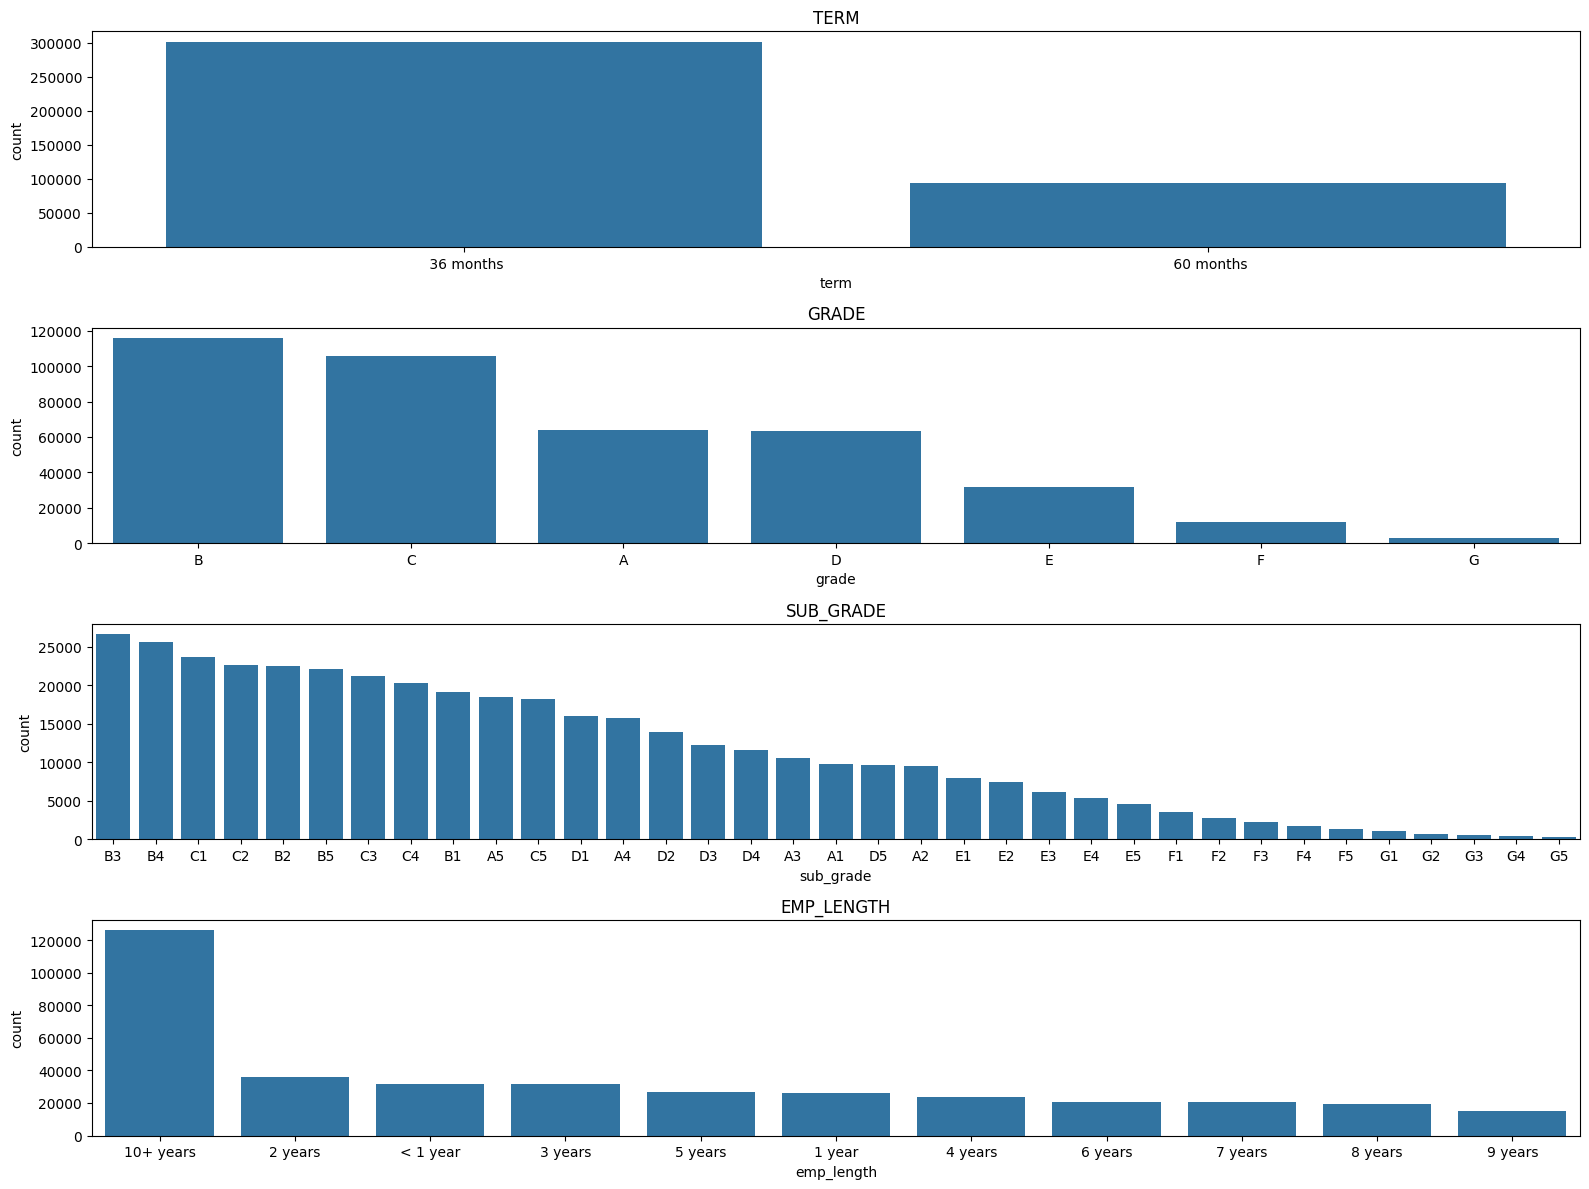

In [ ]:
i=1
for col in cat_cols[:4]:
  plt.subplot(4,1,i)
  sns.countplot(x=df[col],order=df[col].value_counts().index)
  plt.title(col.upper())
  i+=1
plt.tight_layout()
plt.show()

Term - The count of borrower with 36 month terms of loan repayment is higher compared to 60 month terms

Grade - Count of Grade B and C are higher then followed by A,D,E,F,G

SubGrade - Count of Grade B3 and B4 is higher compared to others

emp_length - Count of Year of experince of employee is 10+ years is higher then followed by 2 years and others

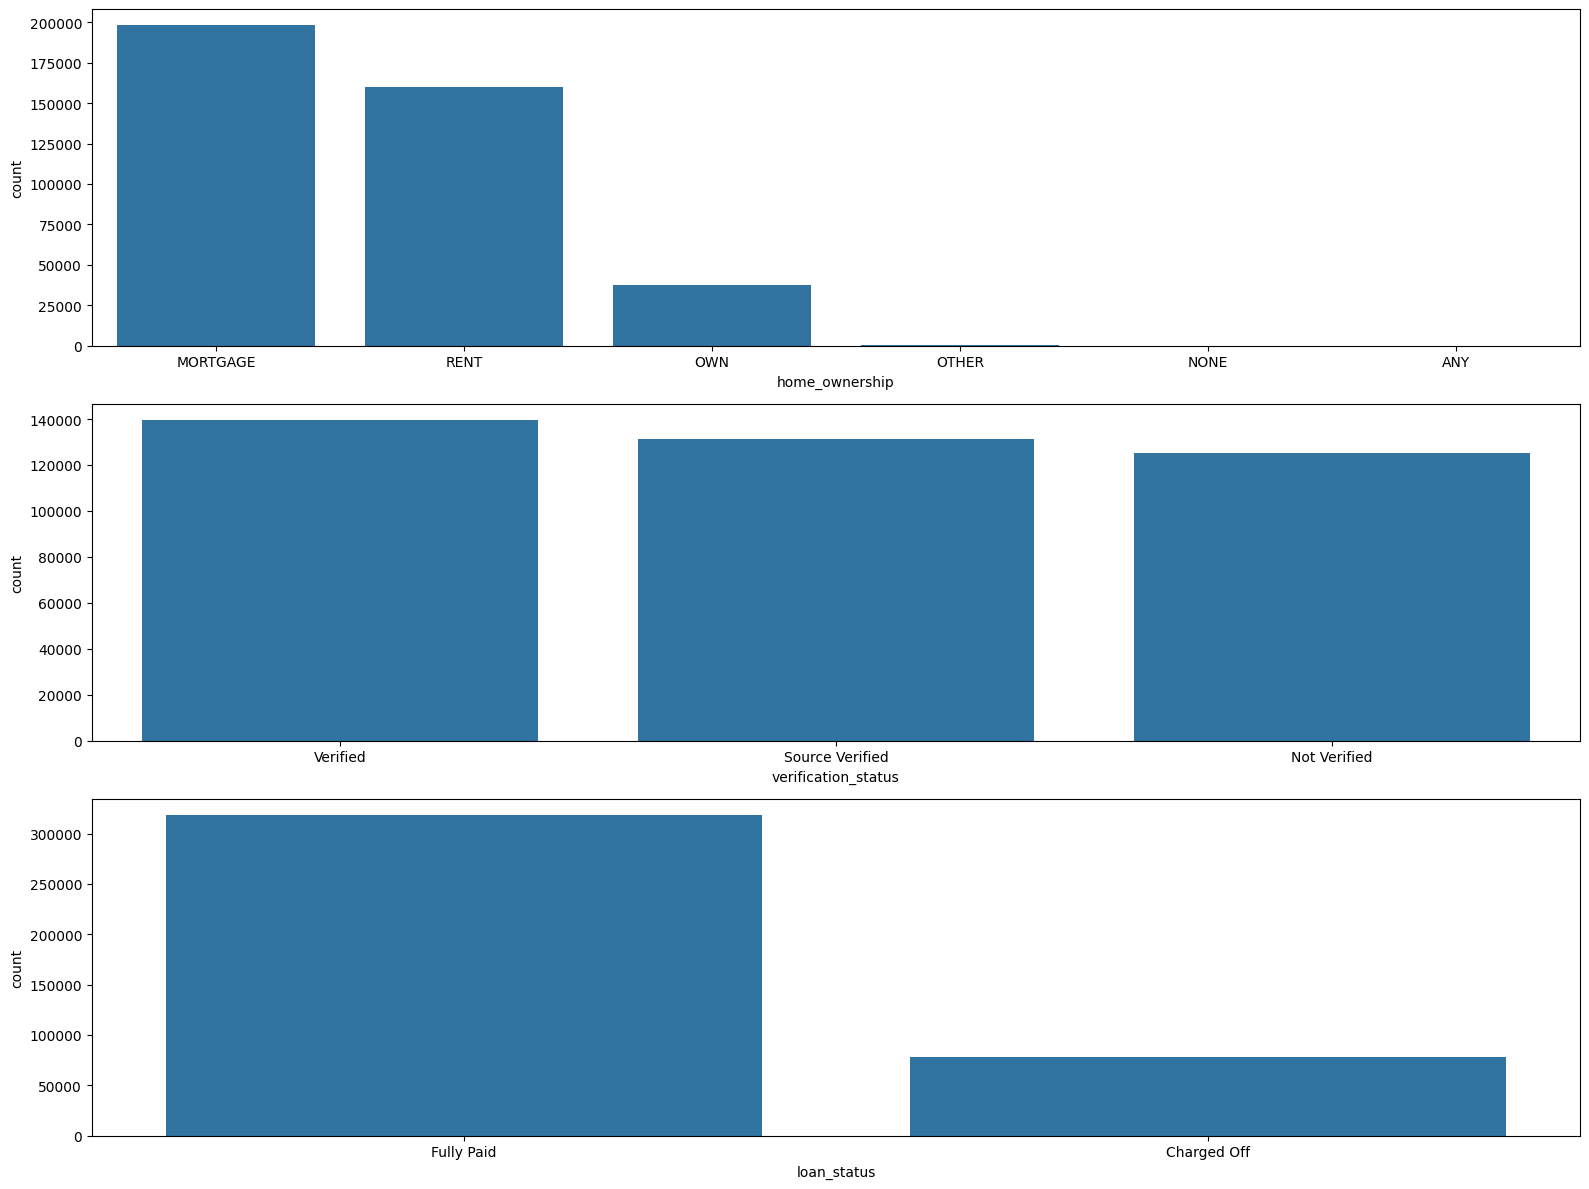

In [ ]:
i=1
for col in cat_cols[4:7]:
  plt.subplot(3,1,i)
  sns.countplot(x=df[col],order=df[col].value_counts().index)
  i+=1
plt.tight_layout()
plt.show()

Home ownership - The Count of  Mortage homes are higher then followed by rent,Own and others

verification status - The count of Verified , Not Verified and Source verified are similar in

Loan status - The count of Fully paid is higher comapred to charged off

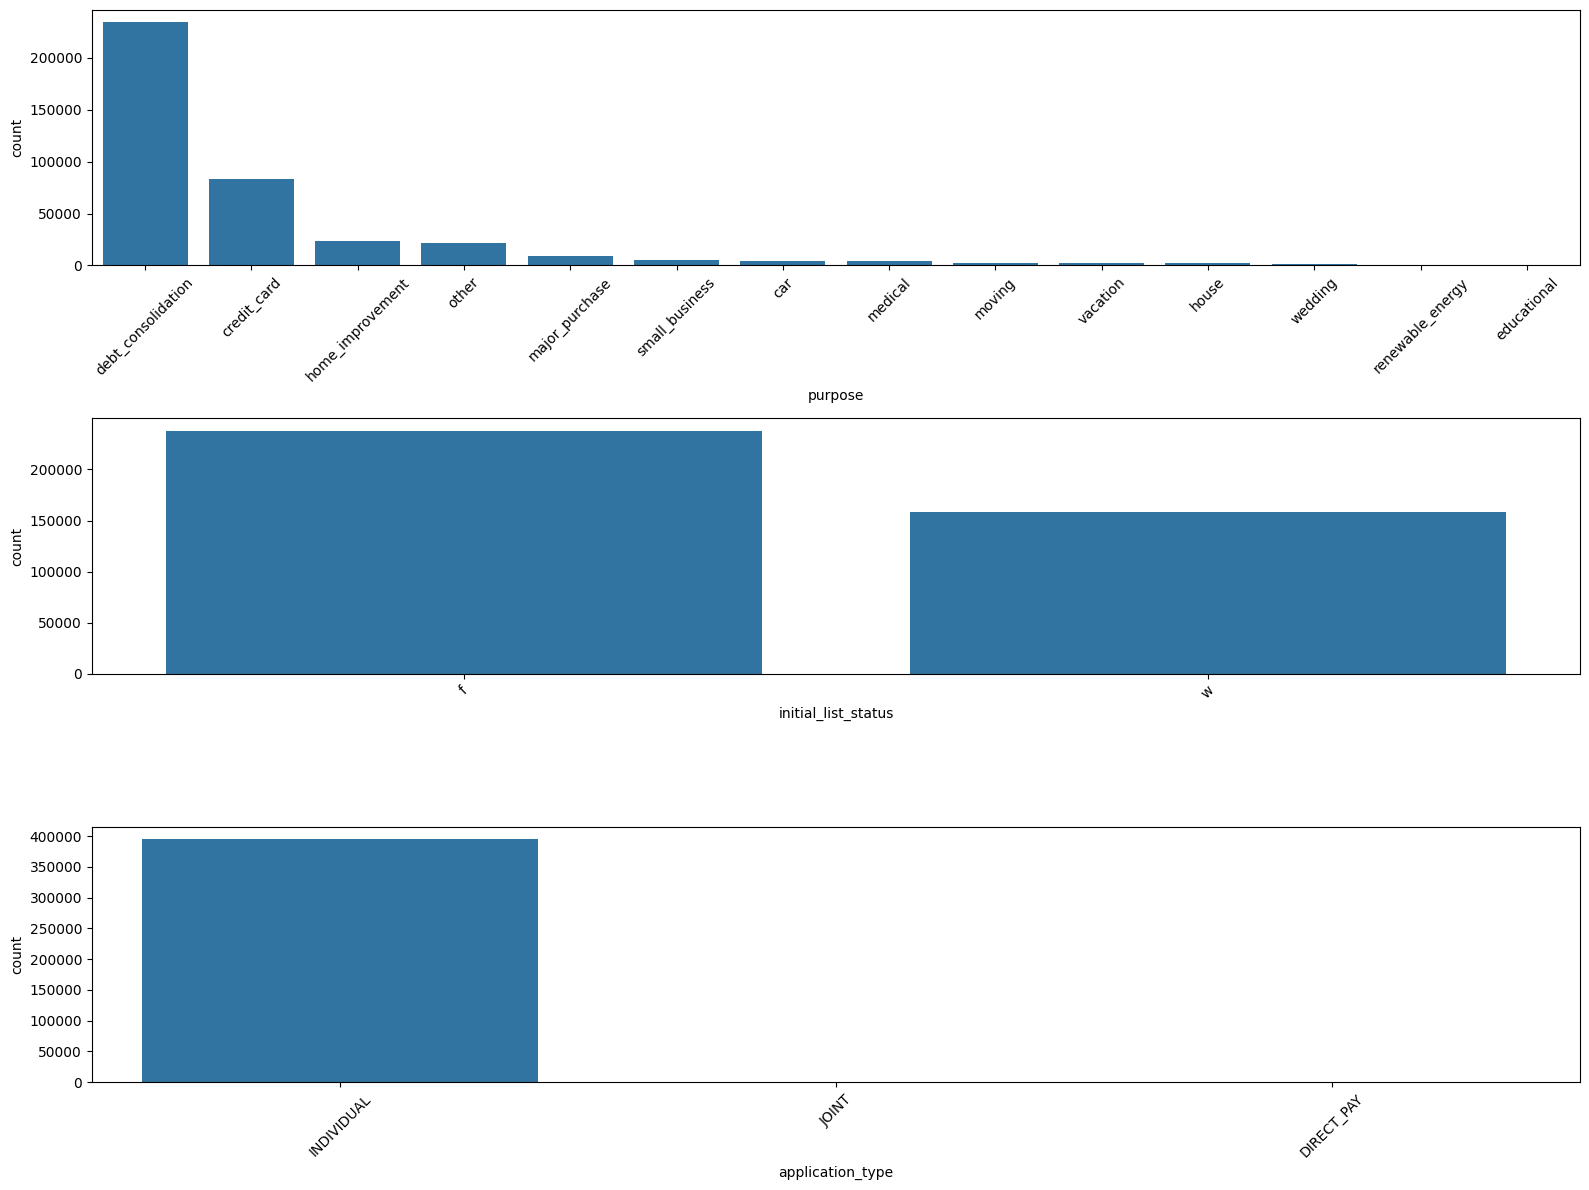

In [ ]:
i=1
for col in cat_cols[7:]:
  plt.subplot(3,1,i)
  sns.countplot(x=df[col],order=df[col].value_counts().index)
  plt.xticks(rotation=45)
  i+=1
plt.tight_layout()
plt.show()

Purpose - The count of debt consolidation is higher

initial_list_status - count of f means fractional loan is higher comapred to w whole loan

Application Type - count Individual is higher comapred to joint and Direct Pay

Visualizing Numerical values using Histplot

In [ ]:
num_cols=df.select_dtypes(['int','float']).columns
num_cols

Index(['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc',
       'pub_rec_bankruptcies'],
      dtype='object')

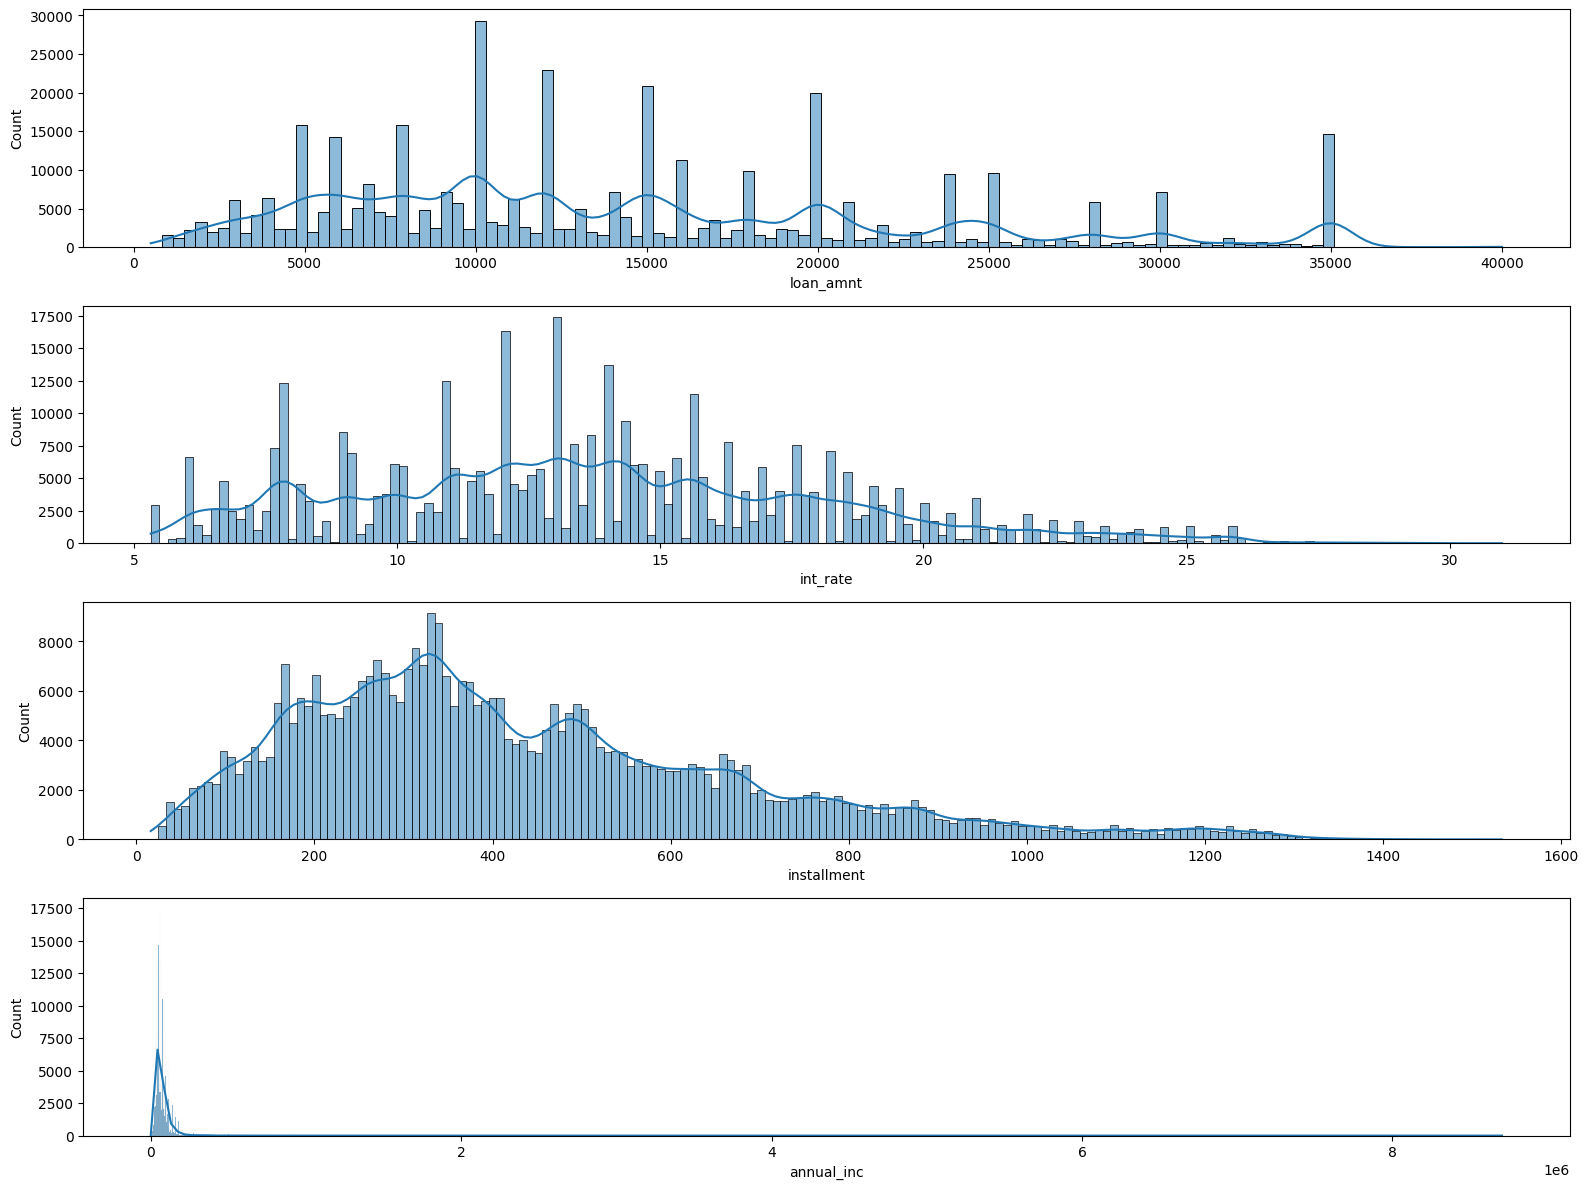

In [ ]:
i=1
for col in num_cols[:4]:
  plt.subplot(4,1,i)
  sns.histplot(x=df[col],kde=True)
  i+=1
plt.tight_layout()
plt.show()

Loan amount and Interest rate are not normally distributed


Installment and annual_inc are right skewed

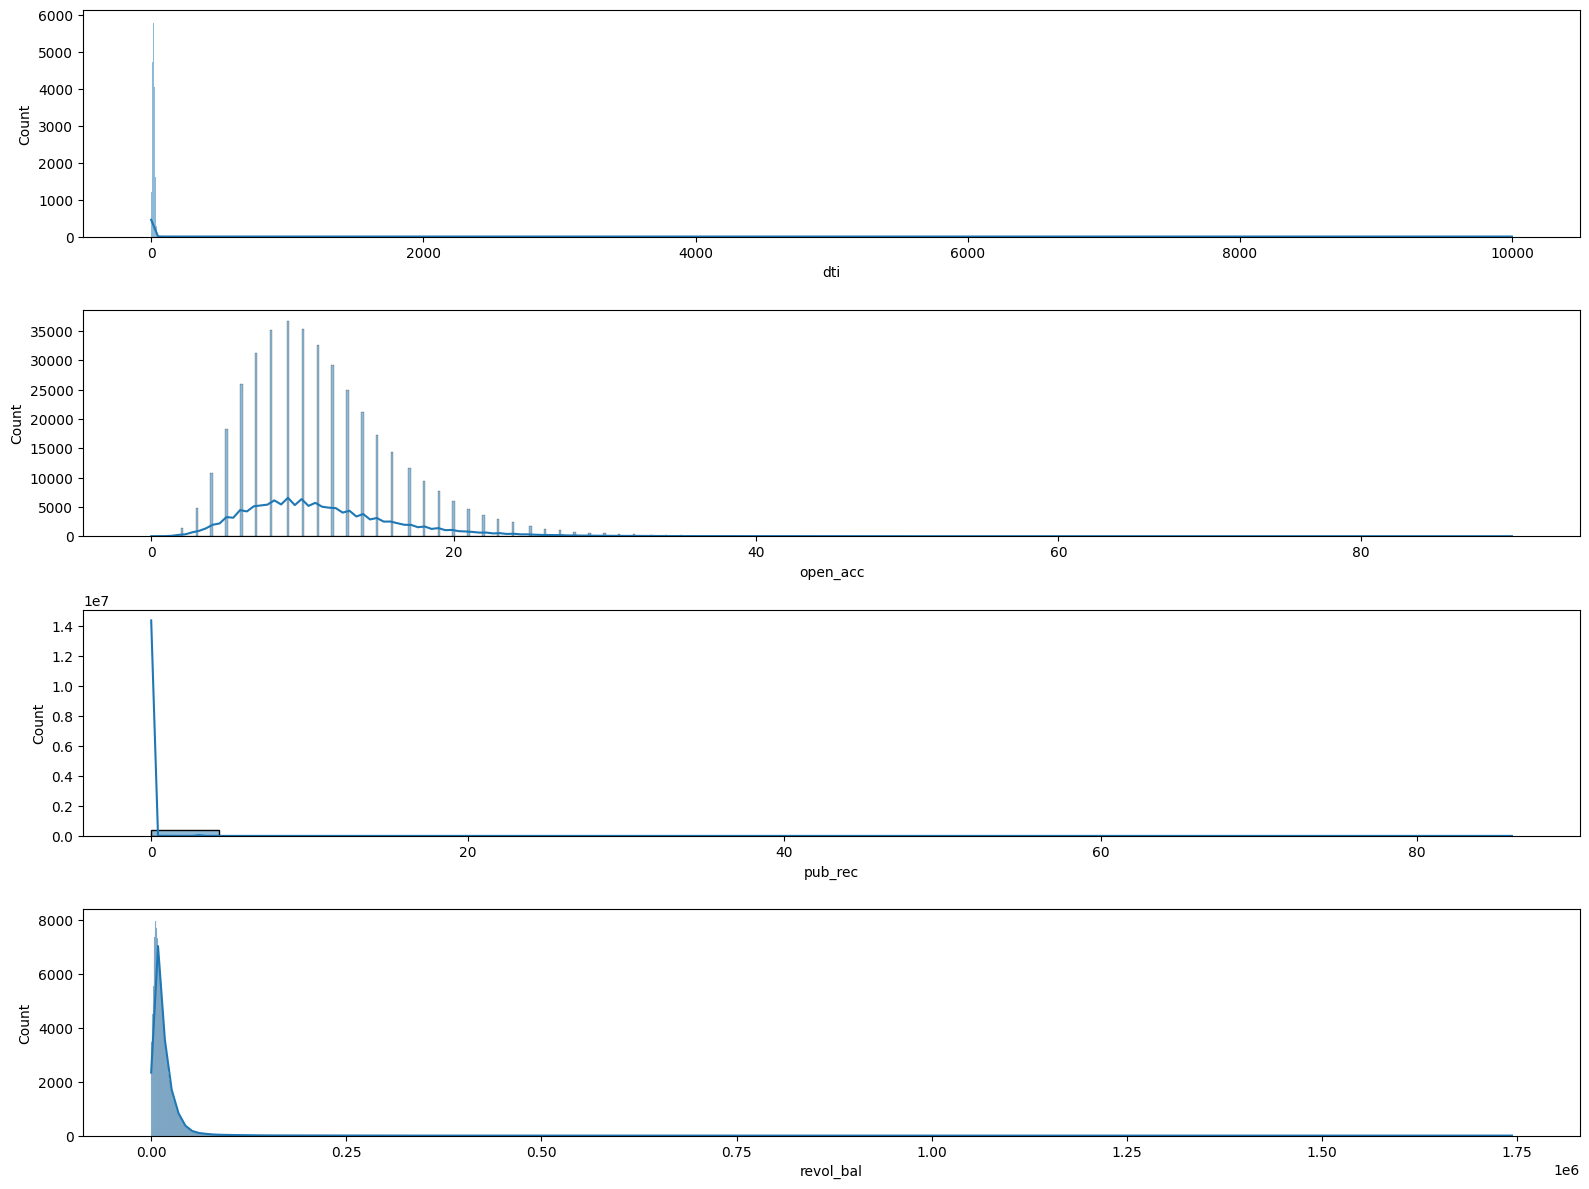

In [ ]:
i=1
for col in num_cols[4:8]:
  plt.subplot(4,1,i)
  sns.histplot(x=df[col],kde=True)
  i+=1
plt.tight_layout()
plt.show()

Revol_bal and DTI are right skewed distribution

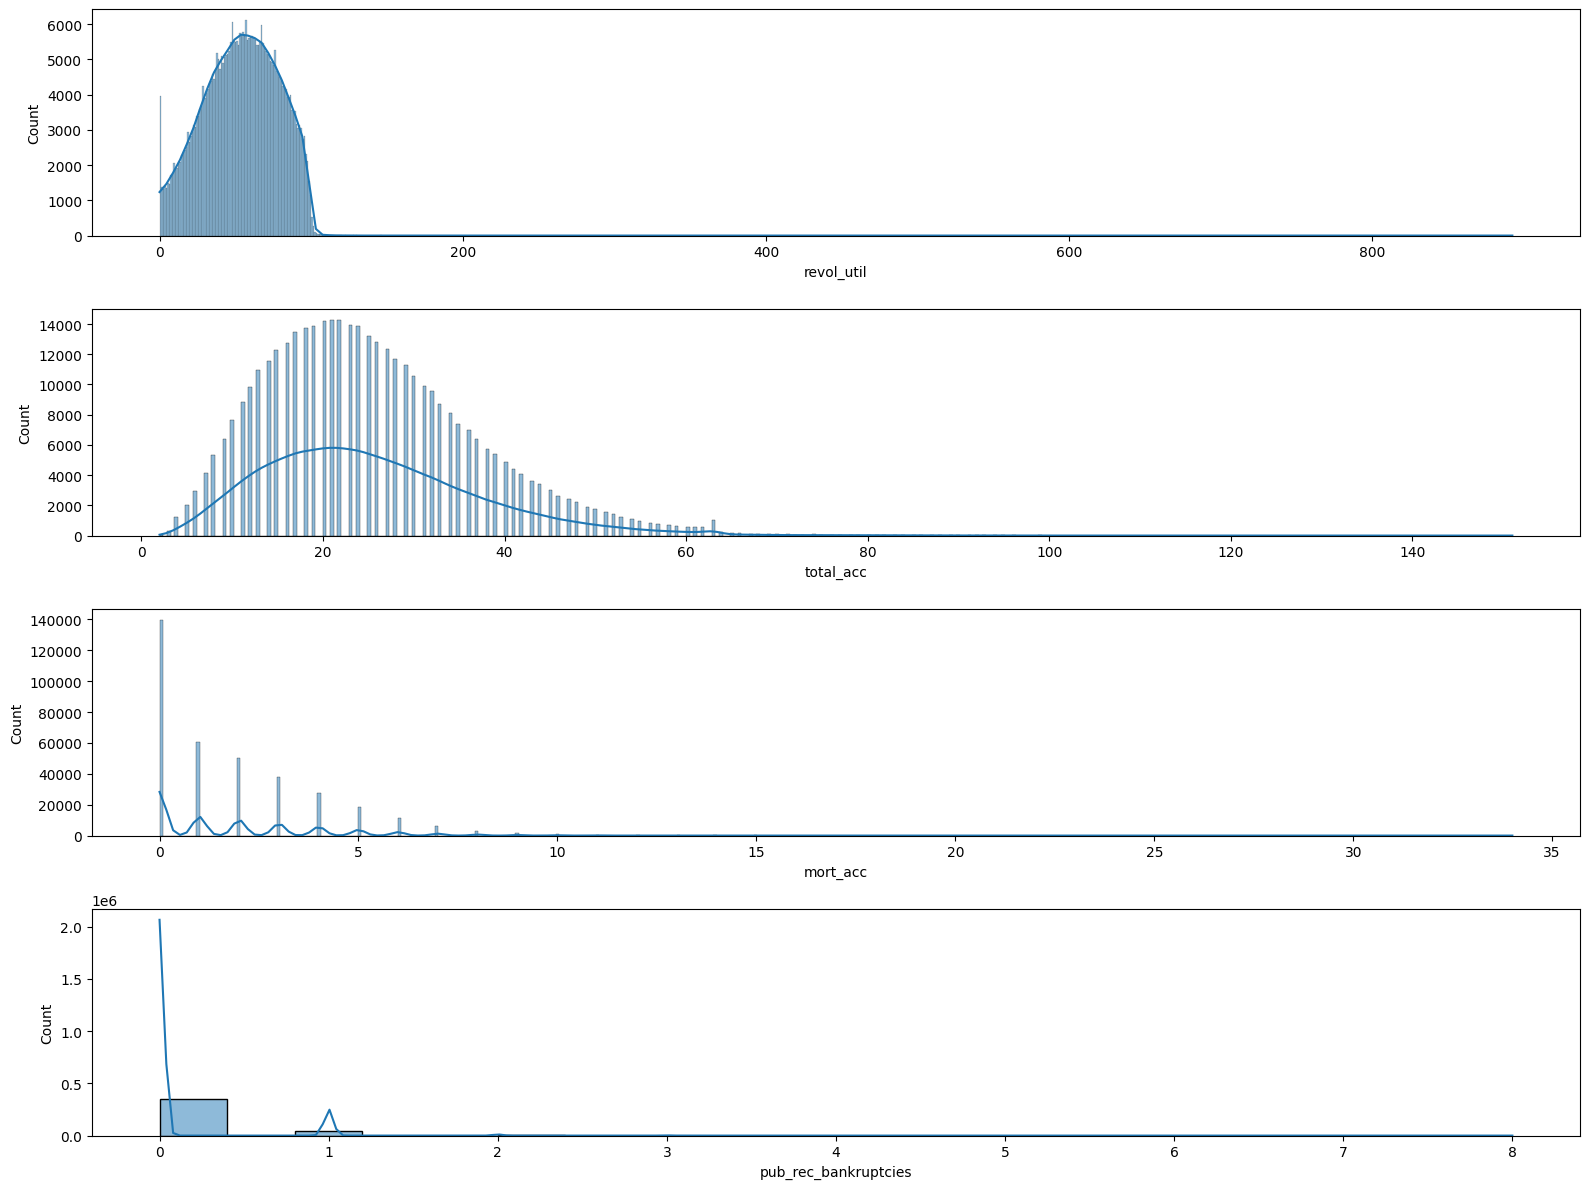

In [ ]:
i=1
for col in num_cols[8:]:
  plt.subplot(4,1,i)
  sns.histplot(x=df[col],kde=True)
  i+=1
plt.tight_layout()
plt.show()

mort_acc and pub_rec_bankruptcies are not normally distributed

revol_util is right skewed distribution

Boxplot using num _ variables

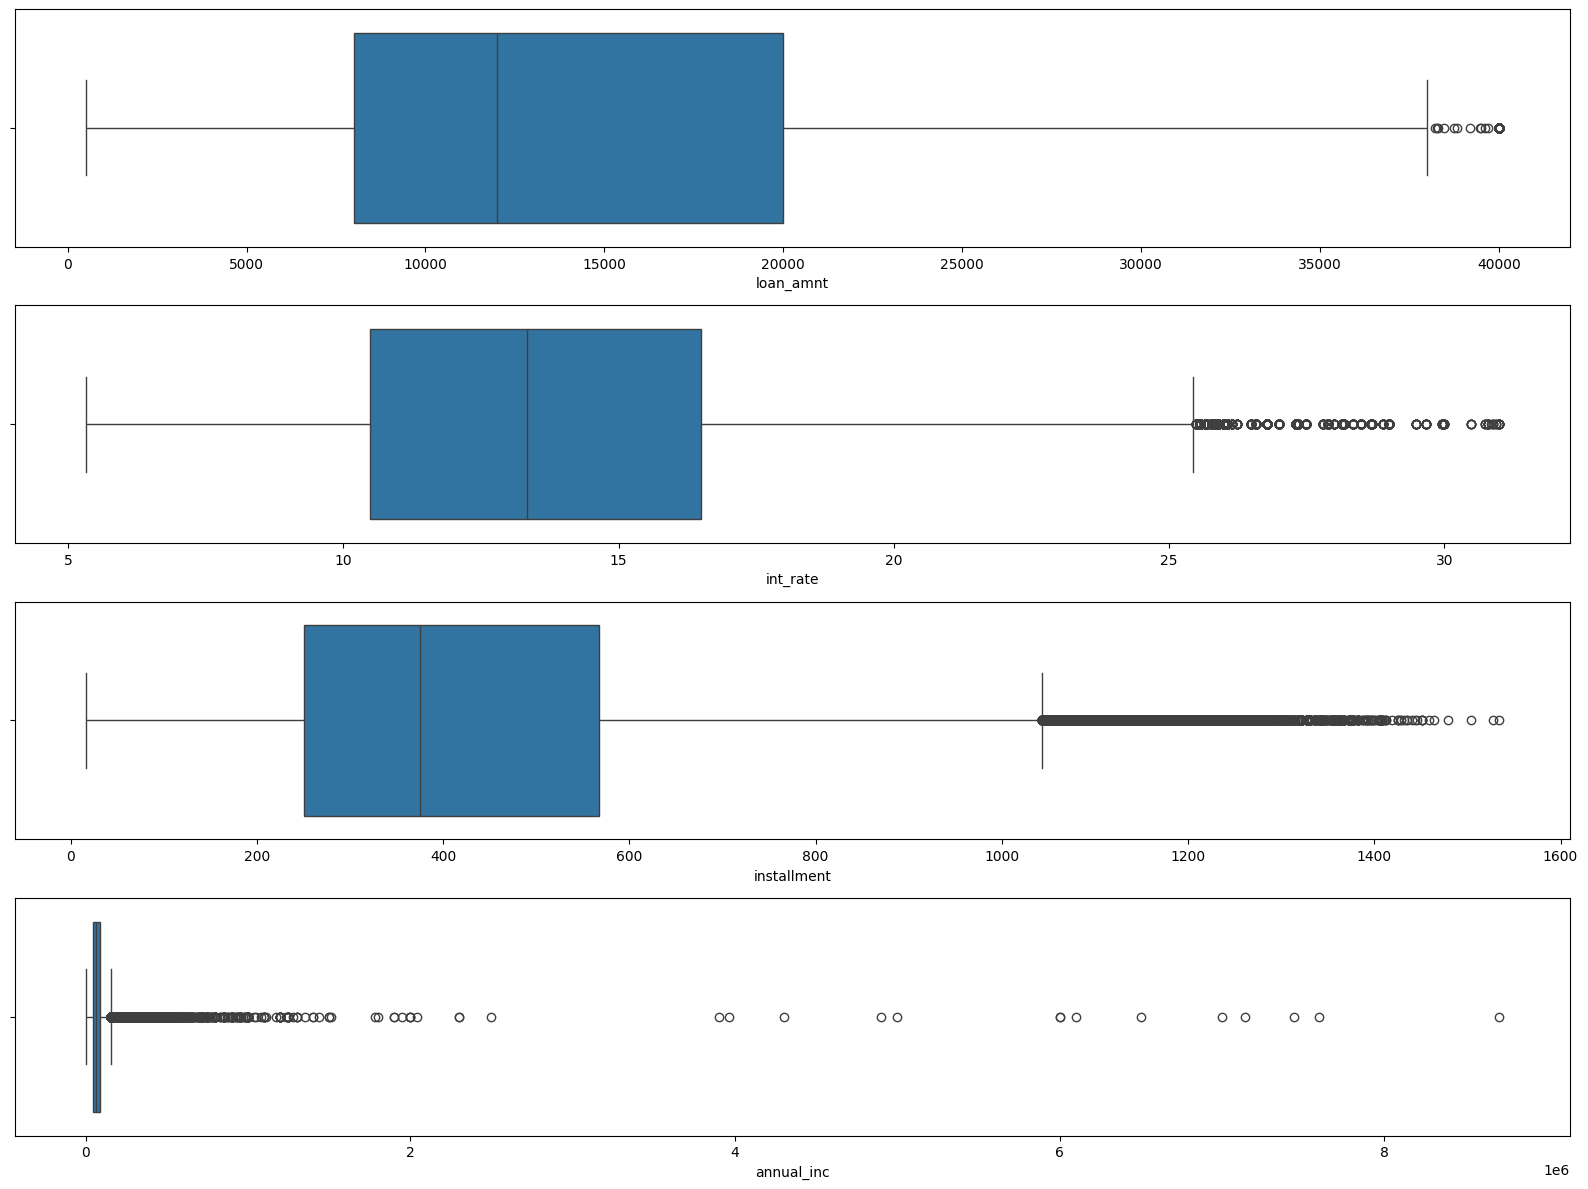

In [ ]:
i=1
for col in num_cols[:4]:
  plt.subplot(4,1,i)
  sns.boxplot(x=df[col])
  i+=1
plt.tight_layout()
plt.show()

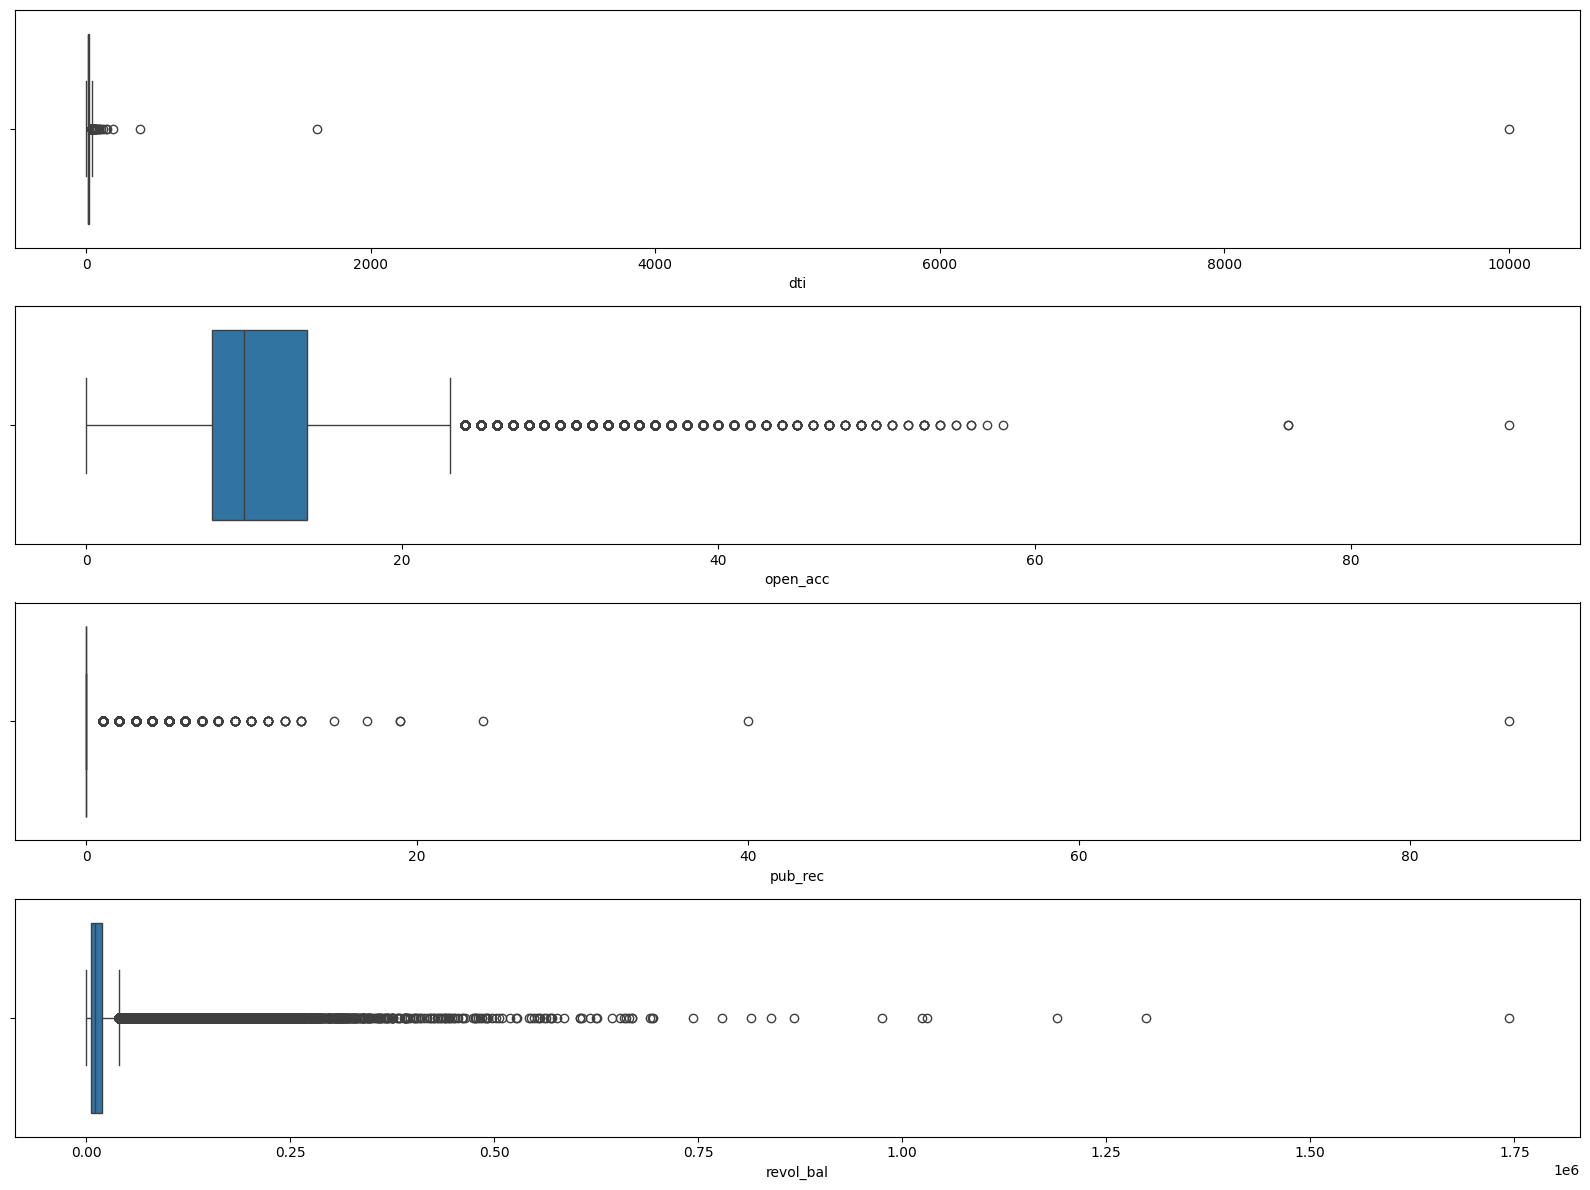

In [ ]:
i=1
for col in num_cols[4:8]:
  plt.subplot(4,1,i)
  sns.boxplot(x=df[col])
  i+=1
plt.tight_layout()
plt.show()

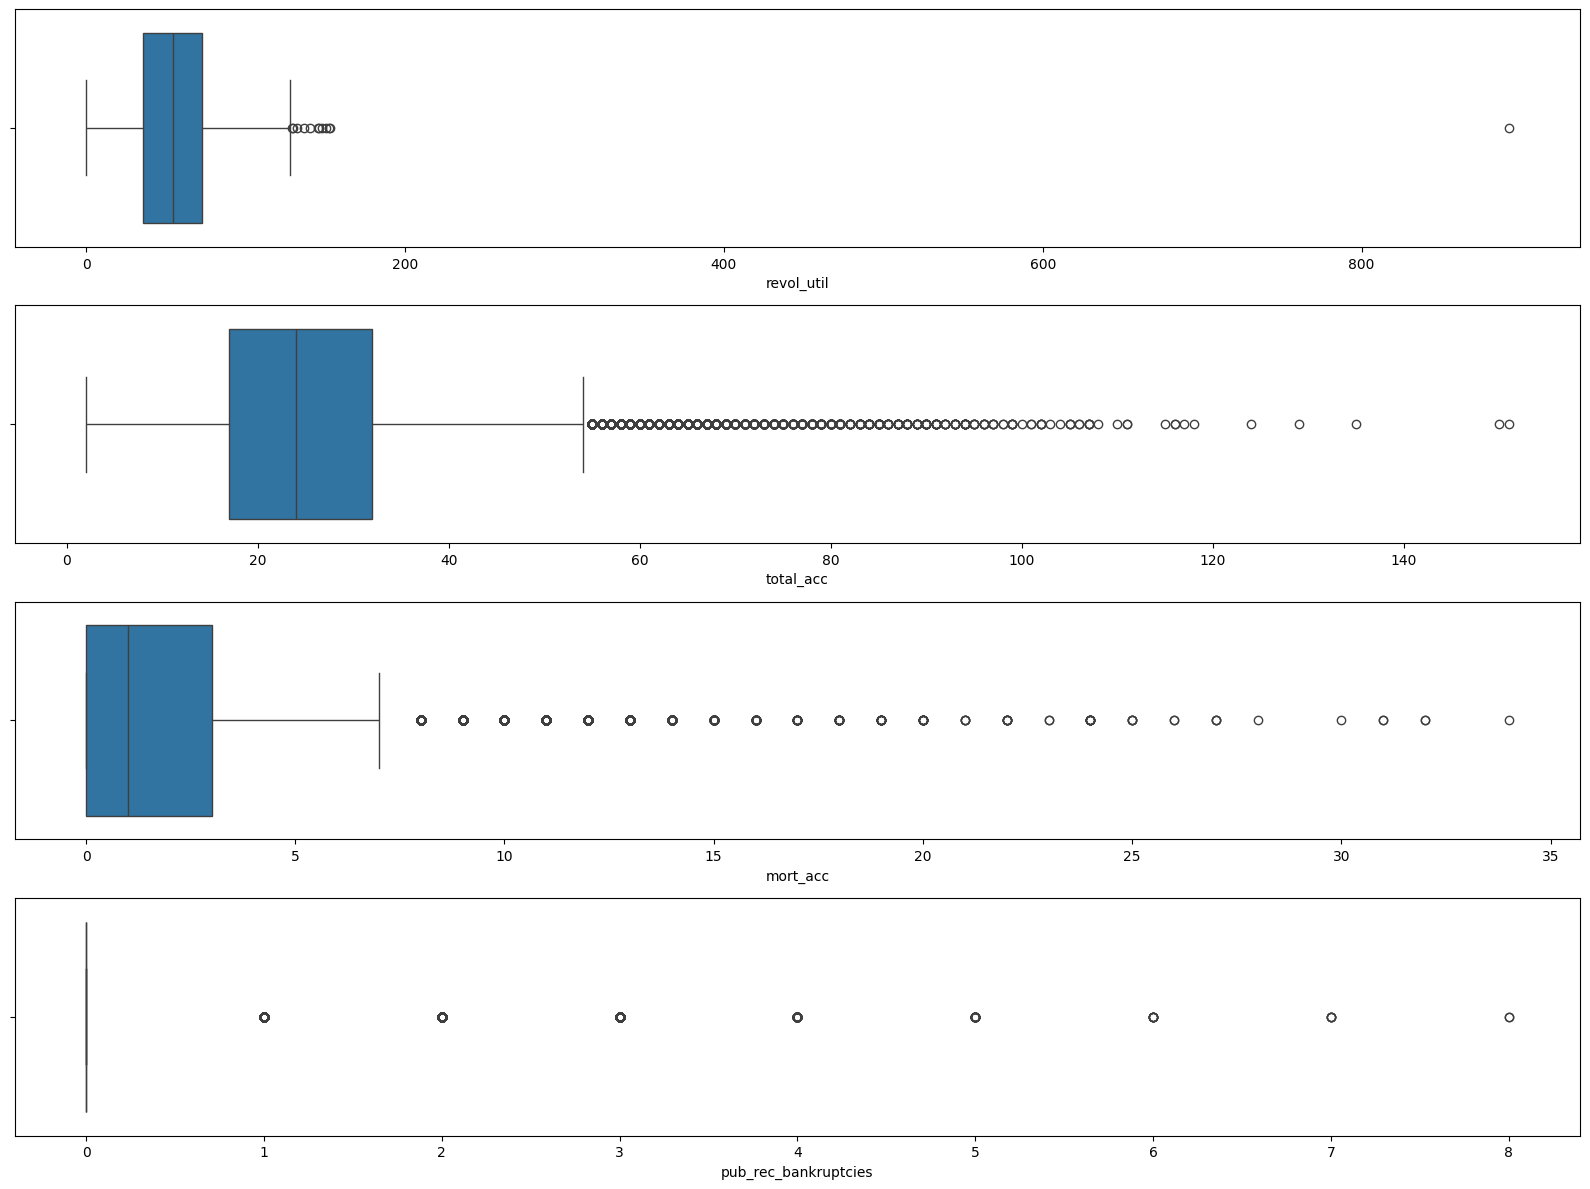

In [ ]:
i=1
for col in num_cols[8:]:
  plt.subplot(4,1,i)
  sns.boxplot(x=df[col])
  i+=1
plt.tight_layout()
plt.show()

Outliers are prest and must be removed

Bivariate analysis

In [ ]:
#countplot

In [ ]:
cat_cols=['term',
 'grade',
 'sub_grade',
 'emp_length',
 'home_ownership',
 'verification_status',
 'purpose',
 'initial_list_status',
 'application_type']

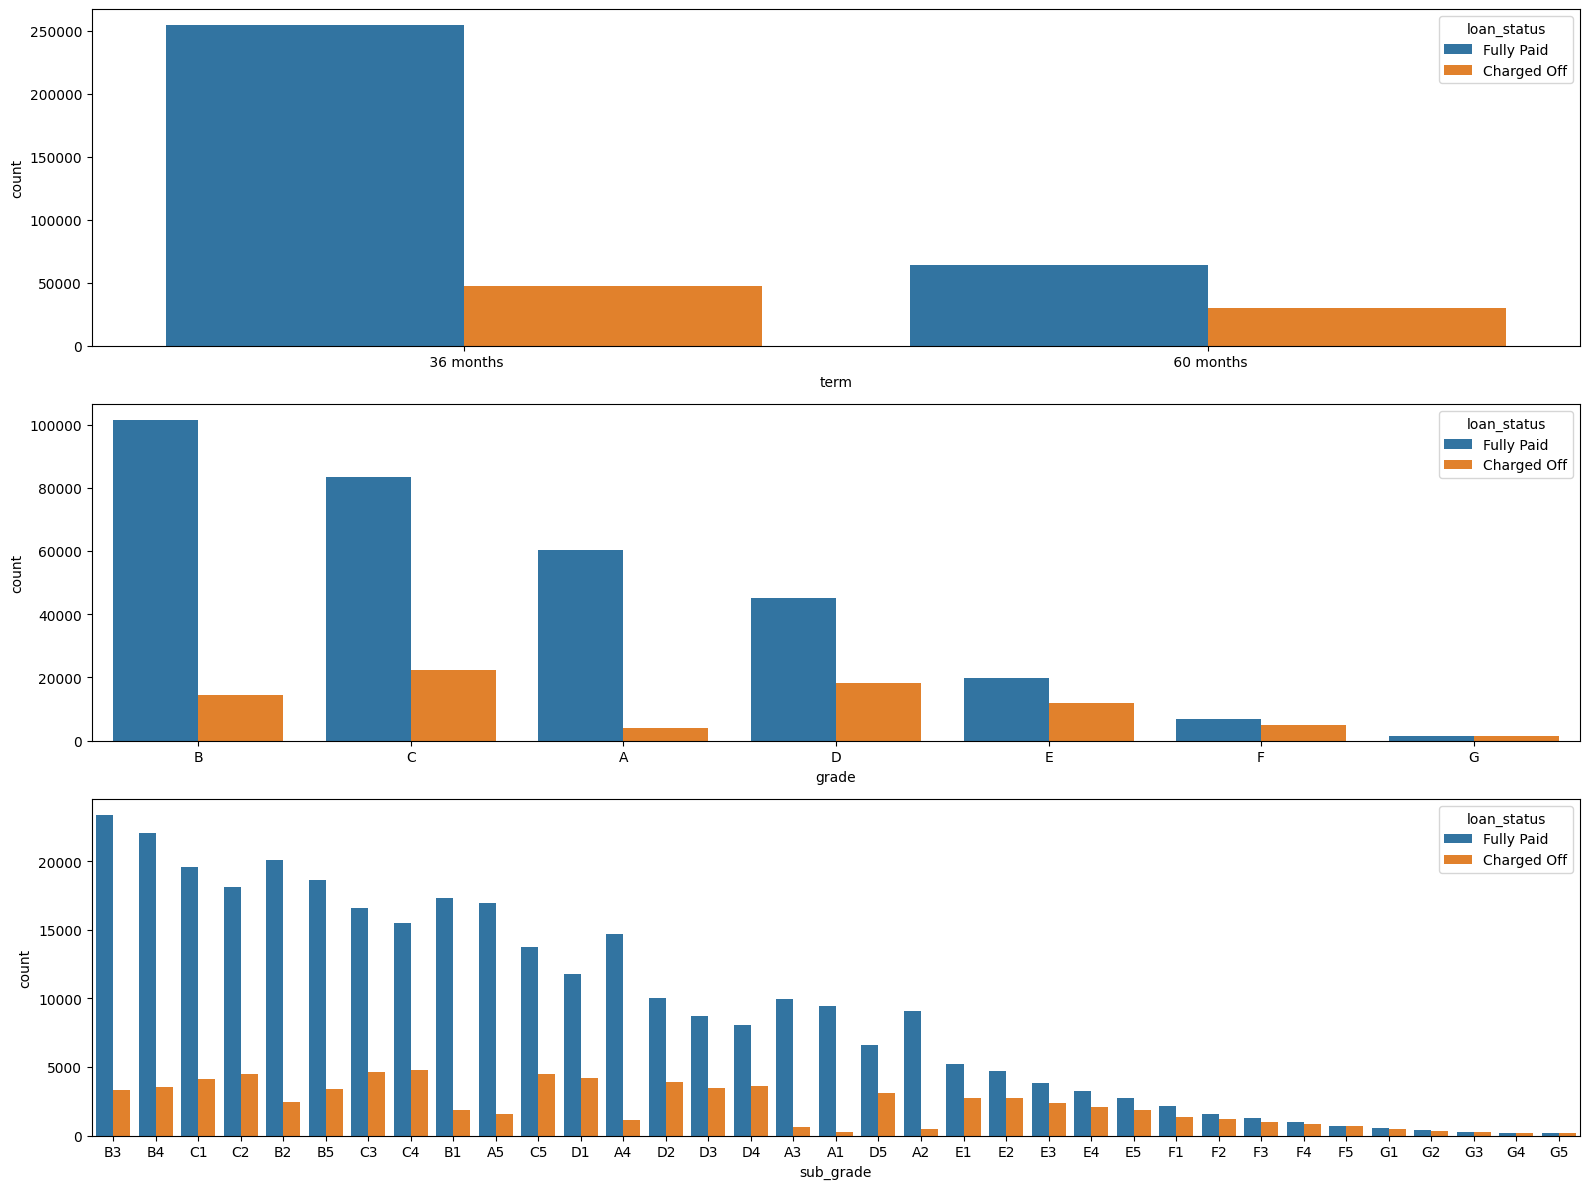

In [ ]:
i=1
for col in cat_cols[:3]:
  plt.subplot(3,1,i)
  sns.countplot(x=df[col],order=df[col].value_counts().index,hue=df['loan_status'])
  i+=1
plt.tight_layout()
plt.show()

Term - 36 months have higher fully paid comapred to 60 months

Grade - Grade B have fully paid compared to other grades

SubGrade - Sub Grade B3 have fully paid compared to other sub grdaes

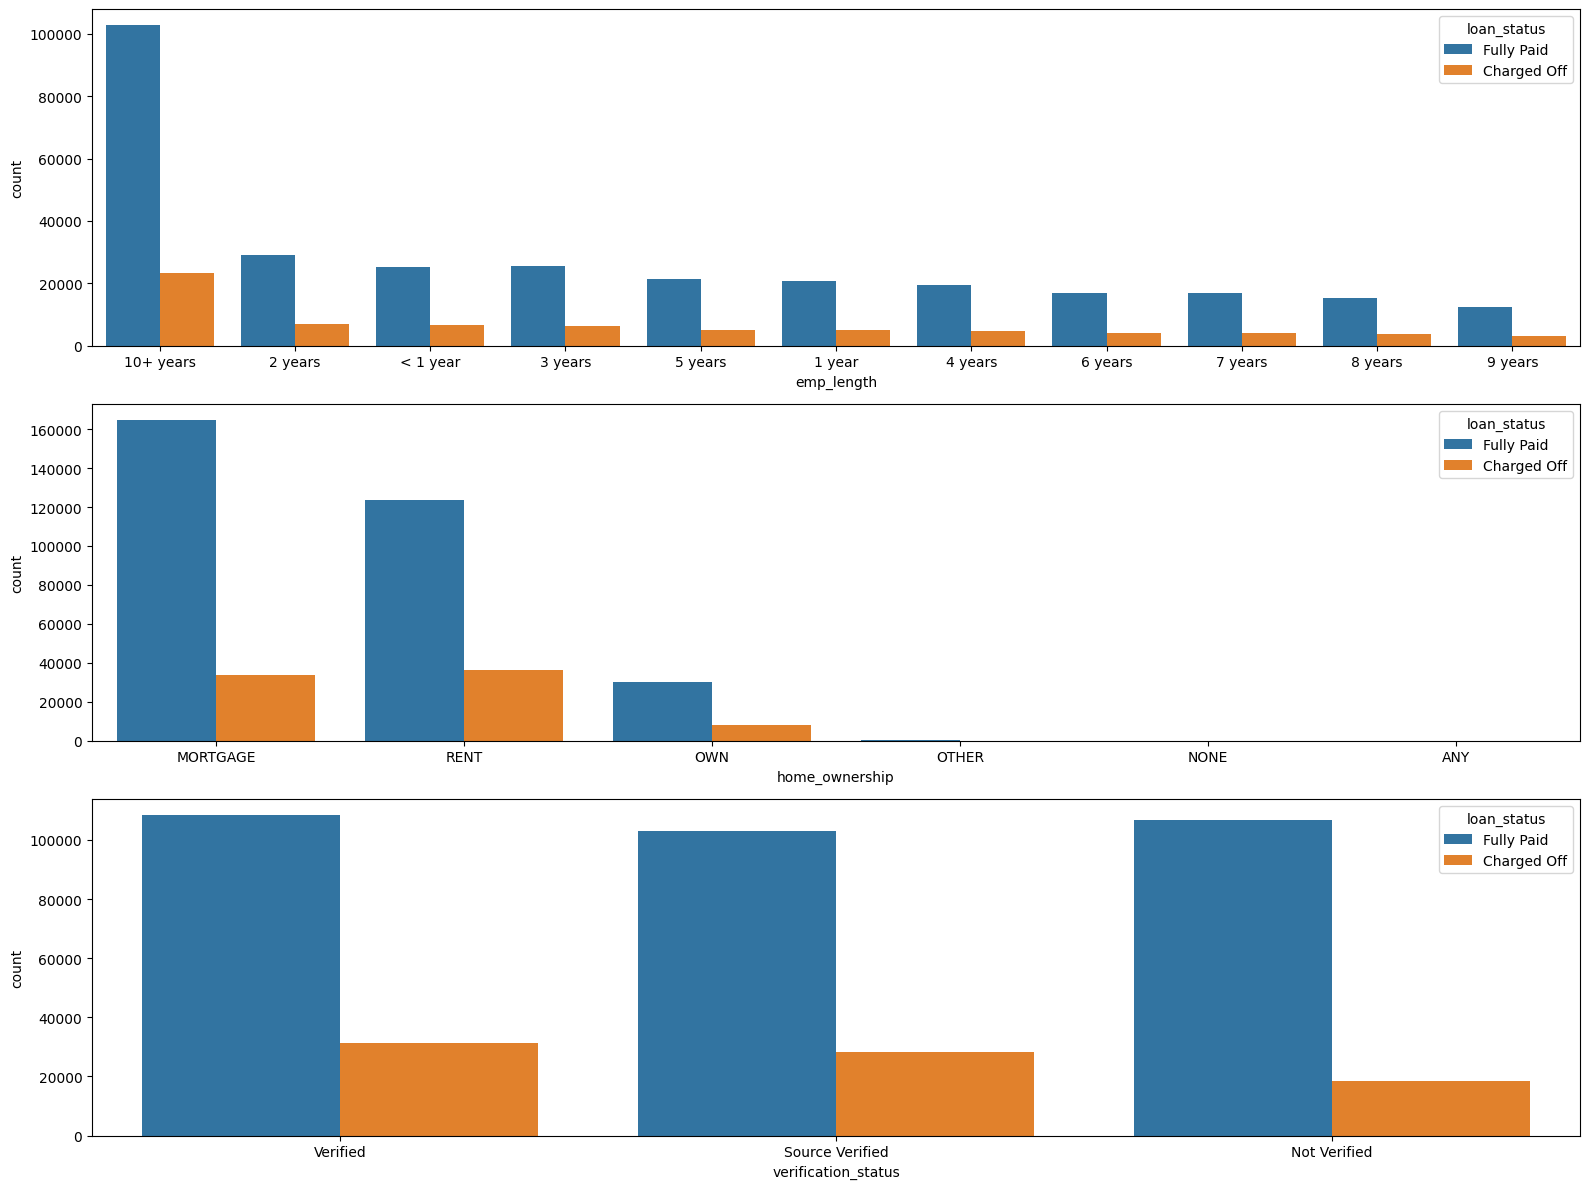

In [ ]:
i=1
for col in cat_cols[3:6]:
  plt.subplot(3,1,i)
  sns.countplot(x=df[col],order=df[col].value_counts().index,hue=df['loan_status'])
  i+=1
plt.tight_layout()
plt.show()

emp_length - 10+ years experience fully paid higher comapred to others

Home_ownership - Mortage has higher fully paid comapred to other home ownership

Verification status - Fully paid are similar for all Verified , Source verified and Not verified

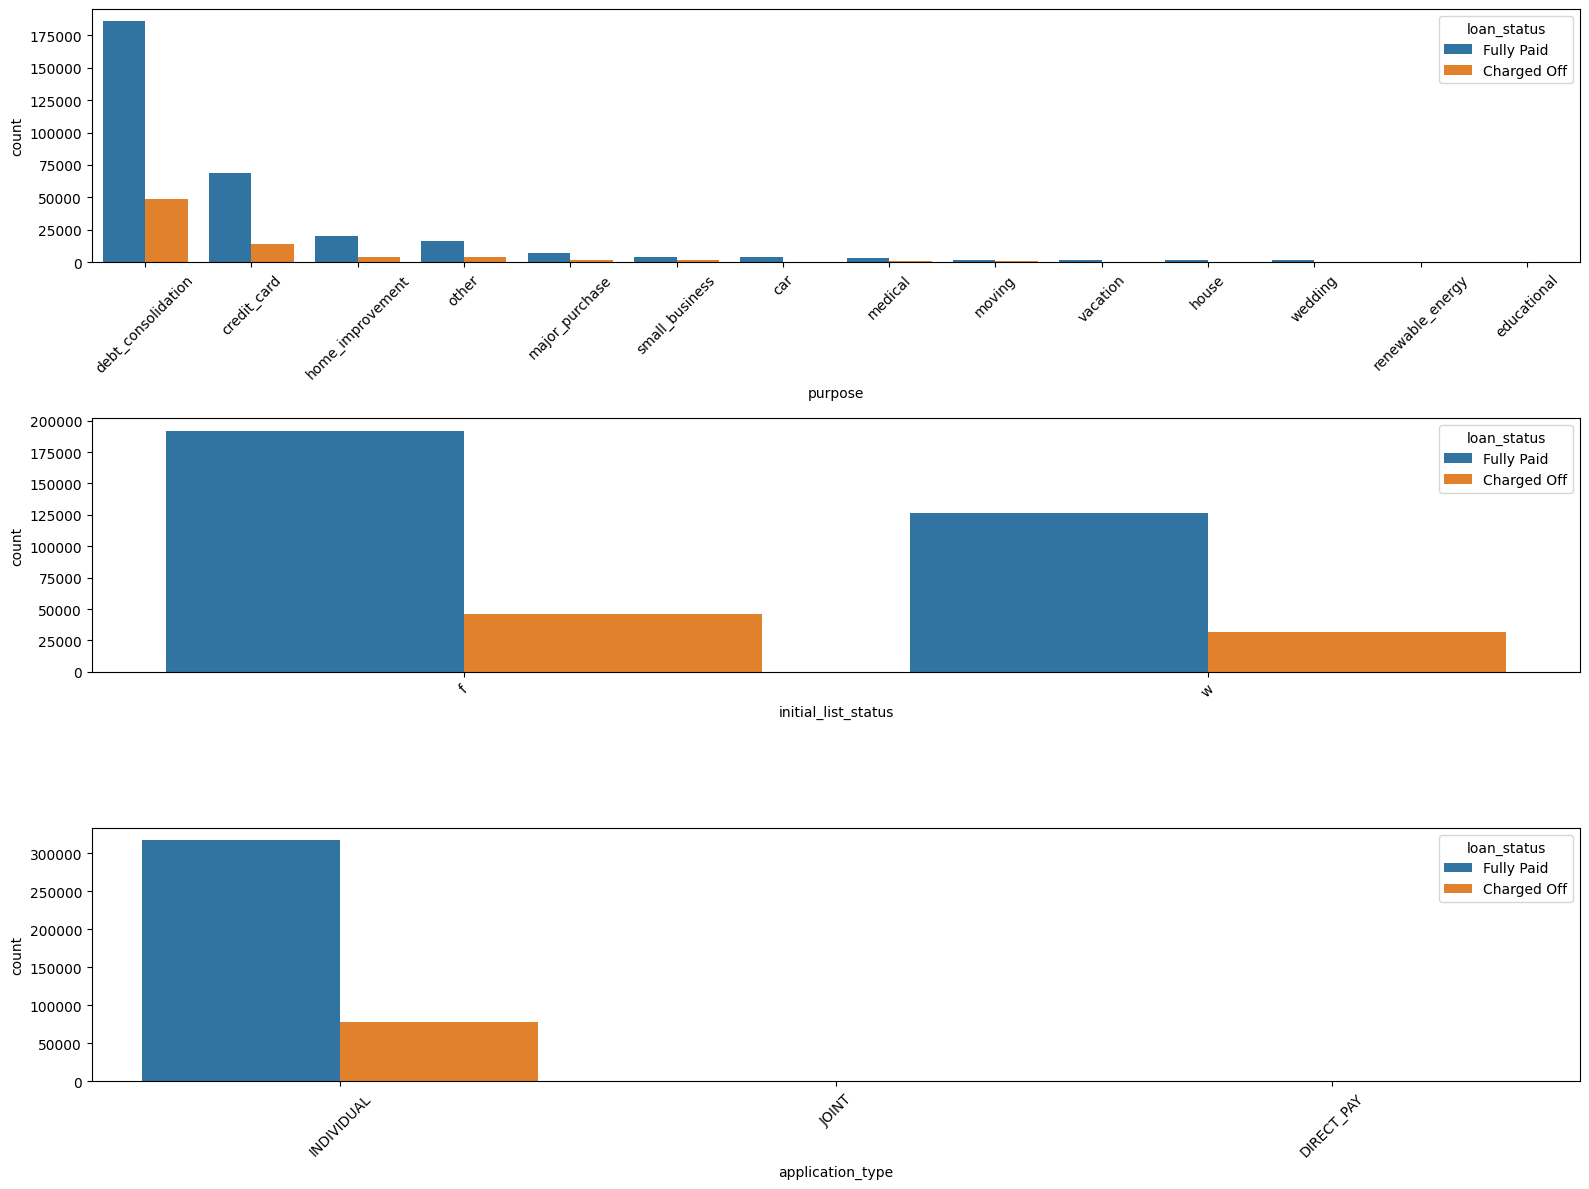

In [ ]:
i=1
for col in cat_cols[6:]:
  plt.subplot(3,1,i)
  sns.countplot(x=df[col],order=df[col].value_counts().index,hue=df['loan_status'])
  plt.xticks(rotation=45)
  i+=1
plt.tight_layout()
plt.show()

purpose - debt consolidation has higher fully paid comapred to others

initial_list_status - f fraction loan paid fully was higher compared to w whole loan

application_type - Individual loan paid fully is comapred to others

Boxplot Bivariate

In [ ]:
num_cols

Index(['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc',
       'pub_rec_bankruptcies'],
      dtype='object')

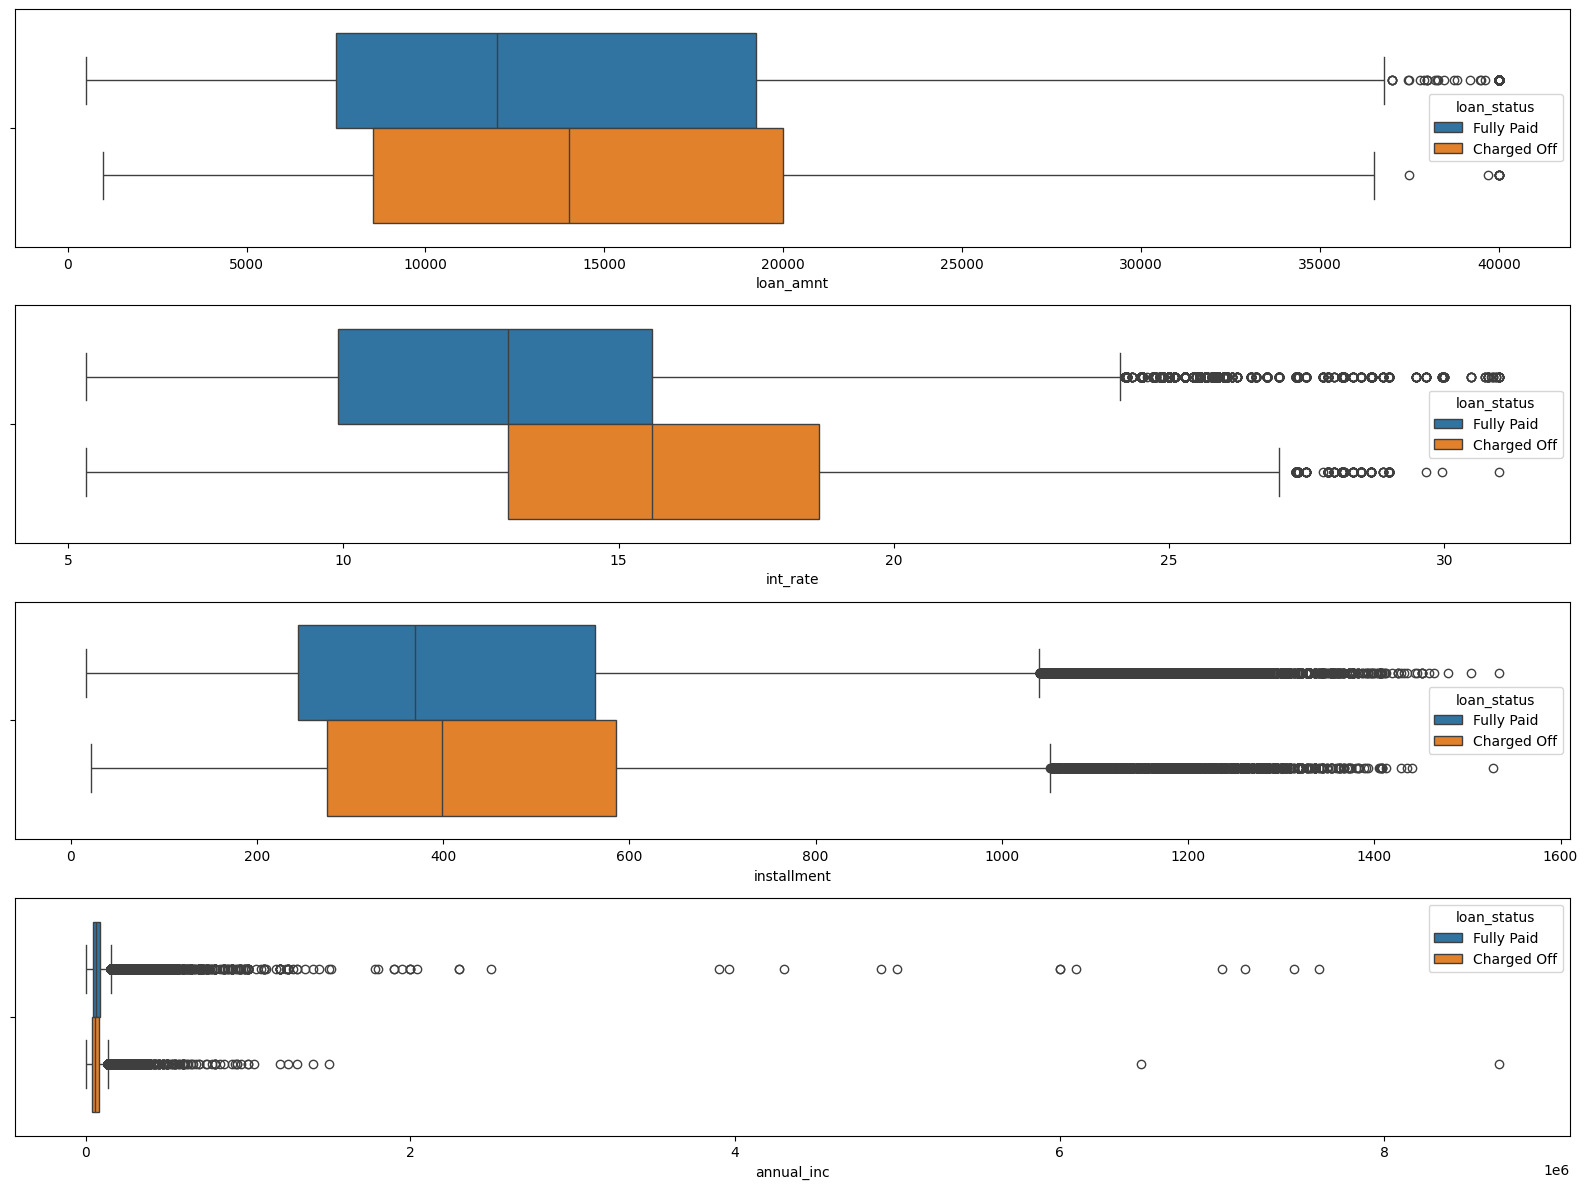

In [ ]:
i=1
for col in num_cols[:4]:
  plt.subplot(4,1,i)
  sns.boxplot(x=df[col],hue=df['loan_status'])
  i+=1
plt.tight_layout()
plt.show()

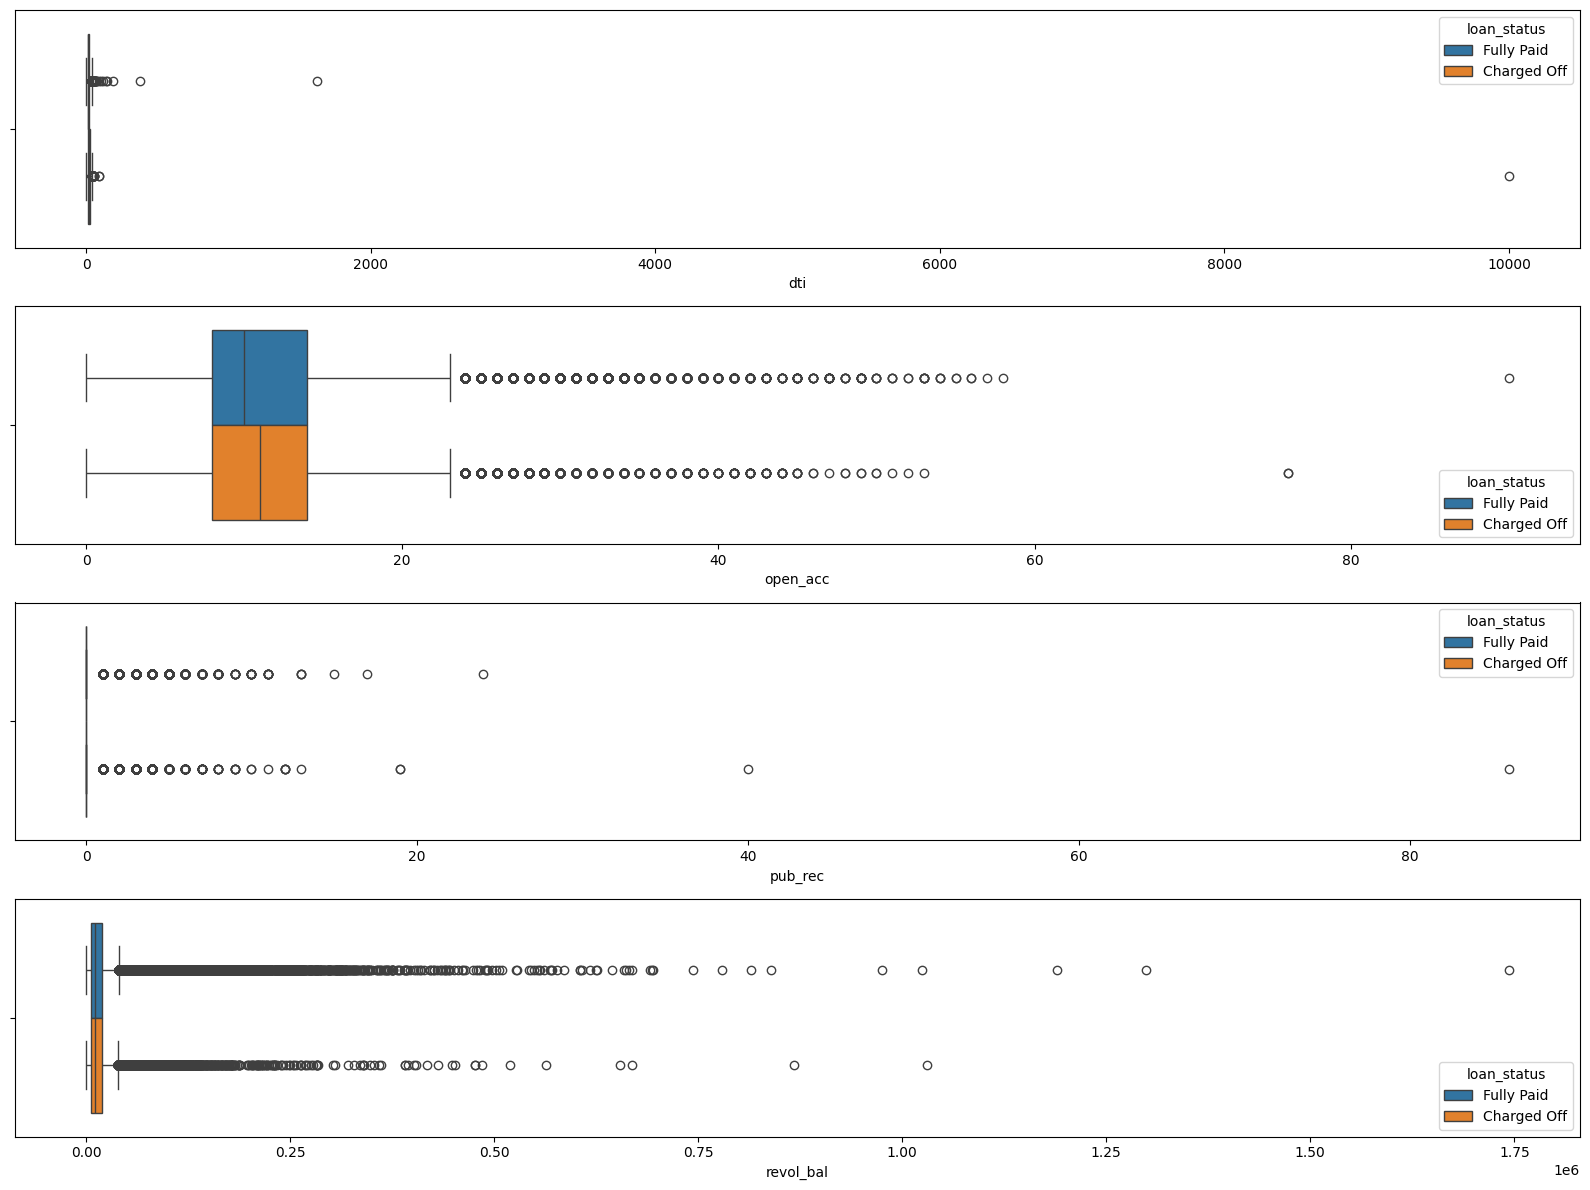

In [ ]:
i=1
for col in num_cols[4:8]:
  plt.subplot(4,1,i)
  sns.boxplot(x=df[col],hue=df['loan_status'])
  i+=1
plt.tight_layout()
plt.show()

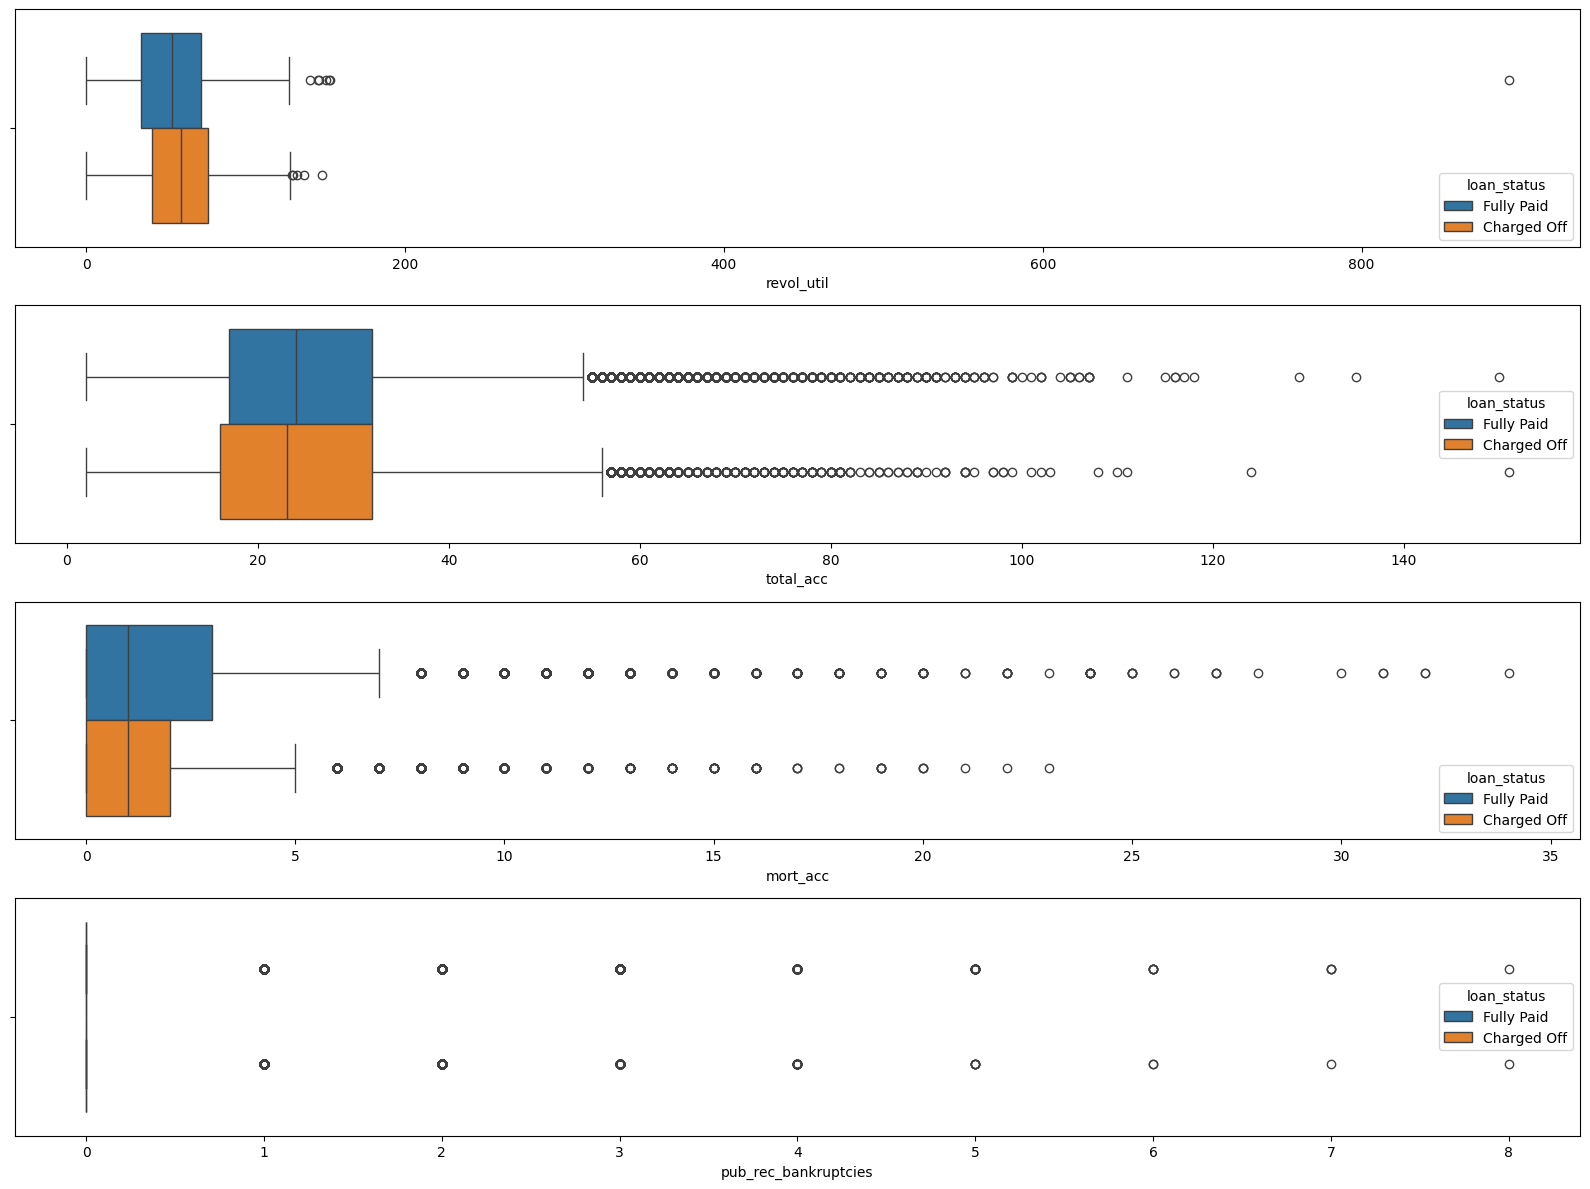

In [ ]:
i=1
for col in num_cols[8:]:
  plt.subplot(4,1,i)
  sns.boxplot(x=df[col],hue=df['loan_status'])
  i+=1
plt.tight_layout()
plt.show()

Outliers are present all the features of loan status fully paid and charged off

Barplot Bivariate

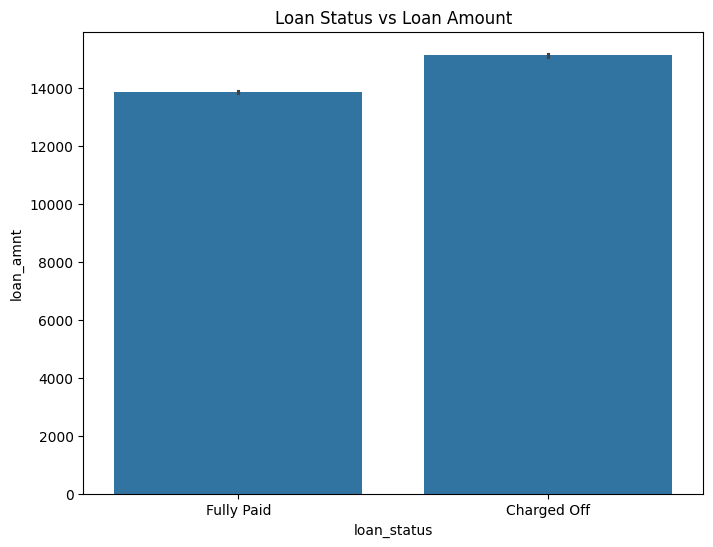

In [ ]:
#Loan status vs Loan amount
plt.figure(figsize=(8,6))
sns.barplot(x=df['loan_status'],y=df['loan_amnt'],estimator='mean')
plt.title('Loan Status vs Loan Amount')
plt.show()

The average Loant amount of charged off is higher comapred to Fully paid means  Generally higher loan amount leads to charged off or not paying according to average

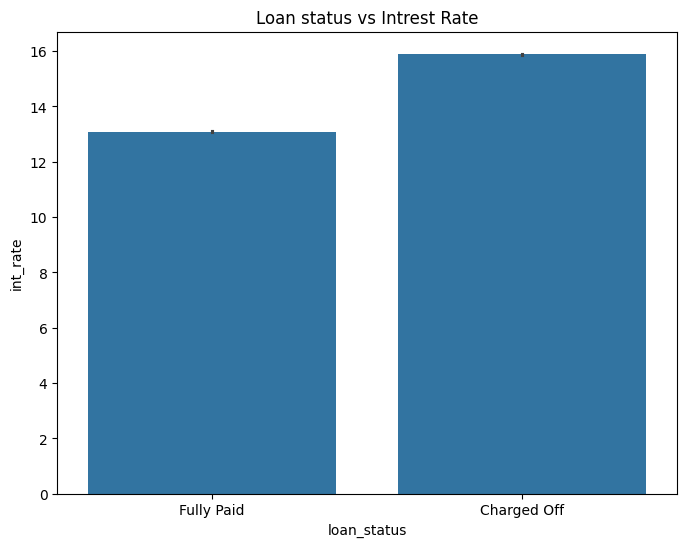

In [ ]:
#Loan Status vs Intrest Rate
plt.figure(figsize=(8,6))
sns.barplot(x=df['loan_status'],y=df['int_rate'],estimator='mean')
plt.title('Loan status vs Intrest Rate')
plt.show()

Charged off of has higher average intrest rate comapred to fully paid intrest rate - if intrest rates are higher the not paying loan is high

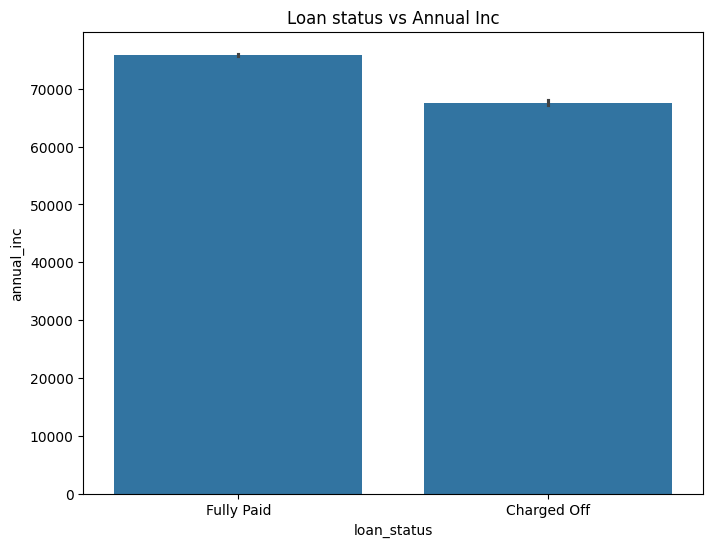

In [ ]:
#Loan status vs Annual Inc
plt.figure(figsize=(8,6))
sns.barplot(x=df['loan_status'],y=df['annual_inc'],estimator='mean')
plt.title('Loan status vs Annual Inc')
plt.show()

Fully paid has higher average annual income comapred to charged off - means that average of annual income higher tends to pay loan fully is higher

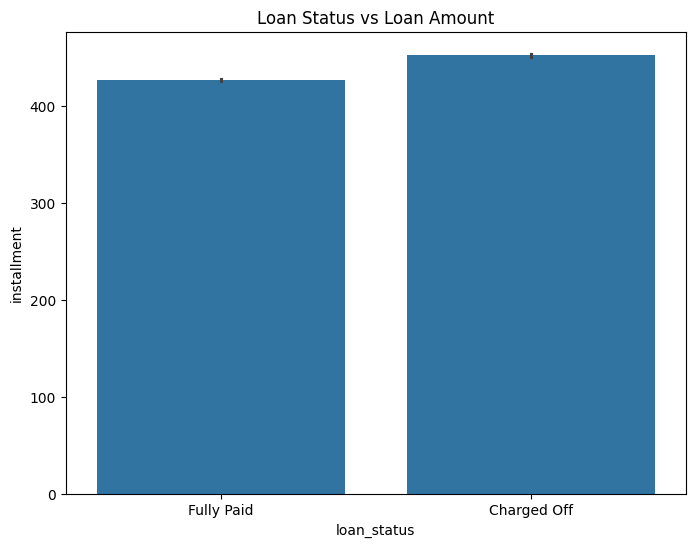

In [ ]:
#Loan status vs Installment
plt.figure(figsize=(8,6))
sns.barplot(x=df['loan_status'],y=df['installment'],estimator='mean')
plt.title('Loan Status vs Loan Amount')
plt.show()

If average installment amount is higher has more charged off comapred to fully paid - so generally if installment amount is lower then it is fully paid

Heatmap

<Axes: >

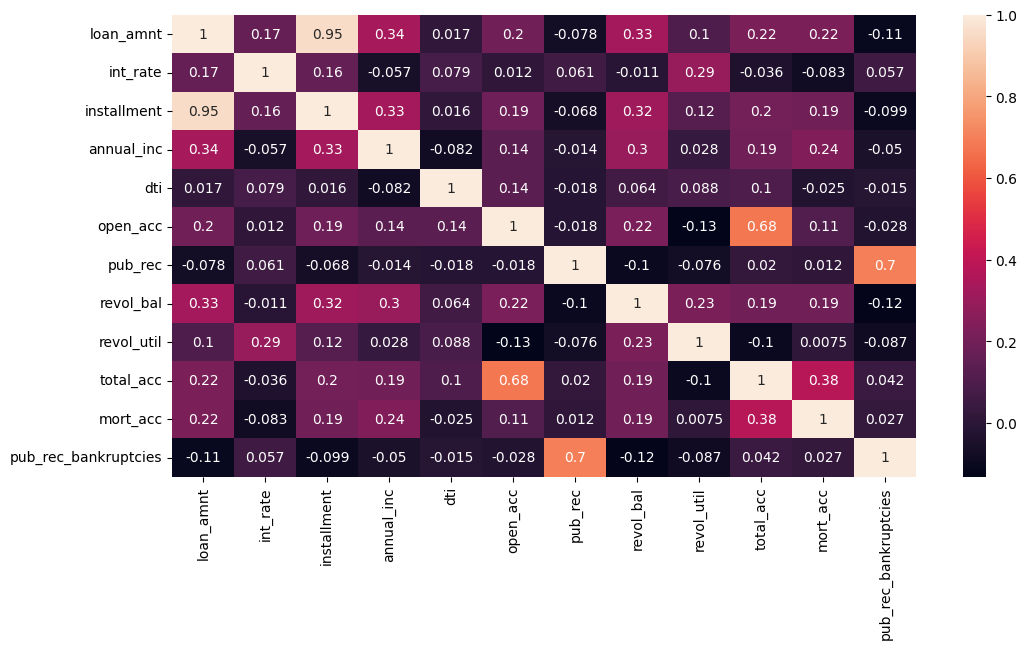

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df.select_dtypes(['int','float']).corr(),annot=True)

In the input Features Loan amount and installment has high multi collinearity with correlation 0.95  

pub_rec and pub_rec_bankruptcies are also higly correlated

open_acc and total_acc are also highly correlated

Simple Feature Engineering

In [ ]:
df1=df.copy()

In [ ]:
df1['term']=df1['term'].str.strip()
df1['term']=df1['term'].apply(lambda x:x.split(" ")[0])
df1['zipcode']=df1['address'].apply(lambda x:x[-5:])

In [ ]:
df1.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address,zipcode
0,10000.0,36,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690",22690
1,8000.0,36,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113",05113
2,15600.0,36,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113",05113
3,7200.0,36,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813",00813
4,24375.0,60,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650",11650


Creation of Flags

 Pub_rec  If value greater than 1.0 then 1 else 0

In [ ]:
def pub_rec1(x):
  if x>1.0:
    return 1
  else:
    return 0
df1['pub_rec']=df1['pub_rec'].apply(pub_rec1)

In [ ]:
df1['pub_rec'].value_counts()

,count
pub_rec,
0,388011
1,8019


Mort_acc

In [ ]:
def mort_acc1(x):
  if x>1.0:
    return 1
  else:
    return 0
df1['mort_acc']=df1['mort_acc'].apply(mort_acc1)

In [ ]:
df1['mort_acc'].value_counts()

,count
mort_acc,
0,237988
1,158042


In [ ]:
def Pub_rec_bankruptcies1(x):
  if x>1.0:
    return 1
  else:
    return 0
df1['pub_rec_bankruptcies']=df1['pub_rec_bankruptcies'].apply(Pub_rec_bankruptcies1)

In [ ]:
df1['pub_rec_bankruptcies'].value_counts()

,count
pub_rec_bankruptcies,
0,393705
1,2325


Duplicate value check


In [ ]:
df1.loc[df1.duplicated()]

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address,zipcode


In [ ]:
df1.duplicated().sum()

np.int64(0)

There are no duplicate values in dataset

Missing value treatment


In [ ]:
pd.DataFrame({'Features':df1.columns,'percentage':(df1.isnull().sum()/len(df1))*100}).reset_index(drop=True)

,Features,percentage
0,loan_amnt,0.000000
1,term,0.000000
2,int_rate,0.000000
3,installment,0.000000
4,grade,0.000000
5,sub_grade,0.000000
6,emp_title,5.789208
7,emp_length,4.621115
8,home_ownership,0.000000
9,annual_inc,0.000000


Percentage of null values all are less thna 6 percent which are acceptable emp_title 5.8 percentage

emp_length 4.6 percentage null values

title 0.4 percentage null values

The emp_title null values are filled with Unknown

In [ ]:
df1['emp_title']=df1['emp_title'].fillna('Unknown')

The emp_length null values are filled with Unknown

In [ ]:
df1['emp_length']=df1['emp_length'].fillna('Unknown')

The title null values are filled with Unknown

In [ ]:
df1['title']=df1['title'].fillna('Unknown')

The revol_util null values are filled with median values

In [ ]:
df1['revol_util']=df1['revol_util'].fillna(df1['revol_util'].median())

In [ ]:
pd.DataFrame({'Features':df1.columns,'percentage':(df1.isnull().sum()/len(df1))*100}).reset_index(drop=True)

,Features,percentage
0,loan_amnt,0.0
1,term,0.0
2,int_rate,0.0
3,installment,0.0
4,grade,0.0
5,sub_grade,0.0
6,emp_title,0.0
7,emp_length,0.0
8,home_ownership,0.0
9,annual_inc,0.0


All the missing values are filled

Outlier Treatment

In [ ]:
num_cols=df1.select_dtypes(['int','float']).columns
num_cols=['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'open_acc', 'revol_bal', 'revol_util', 'total_acc']

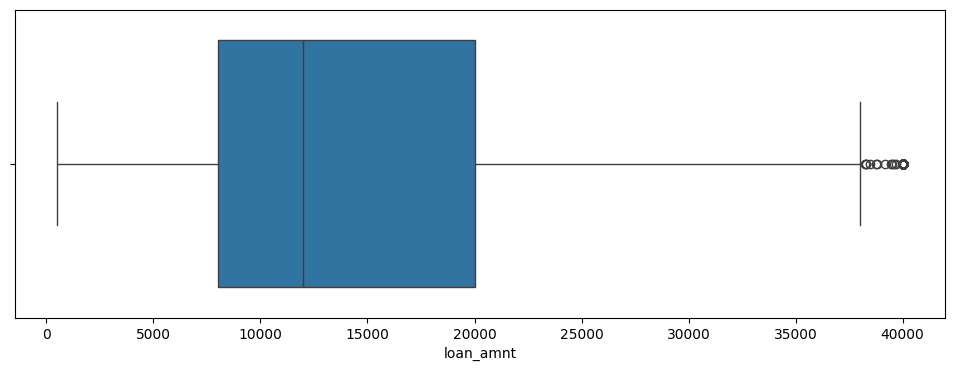

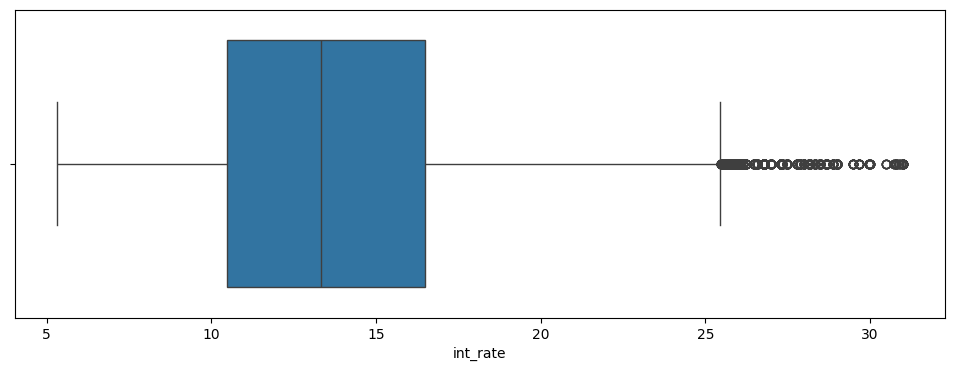

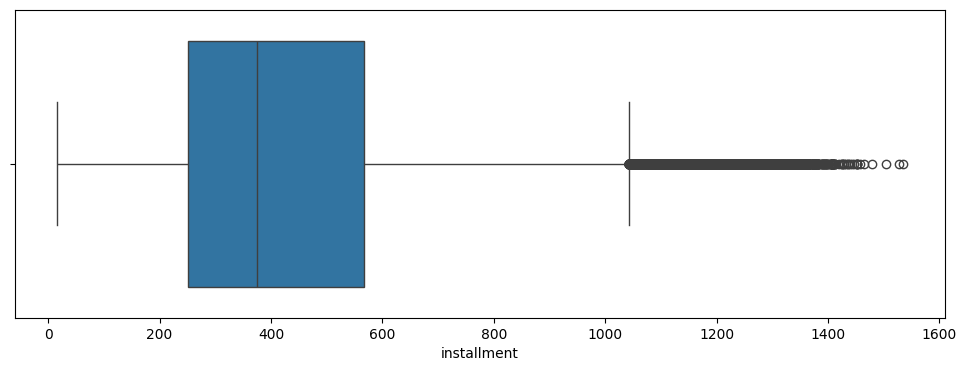

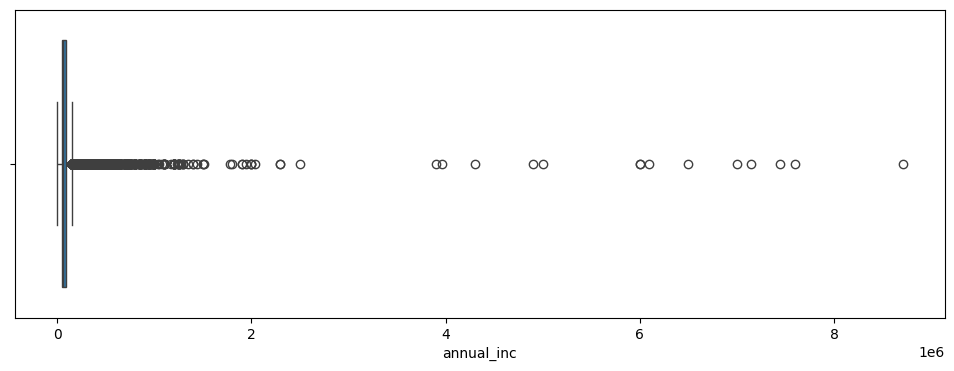

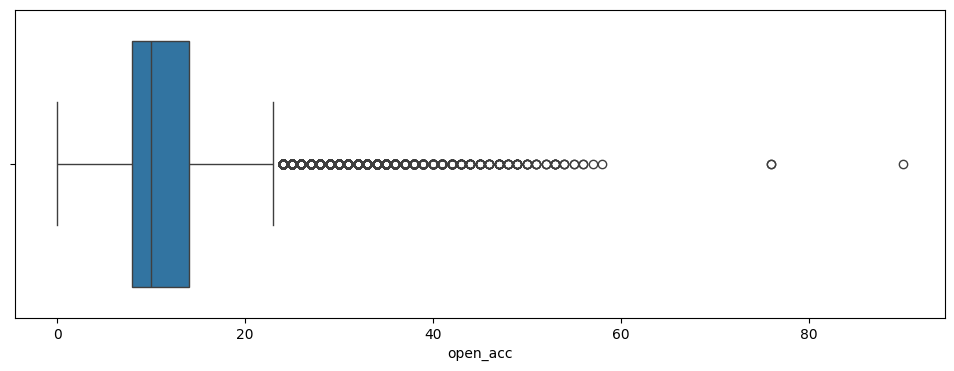

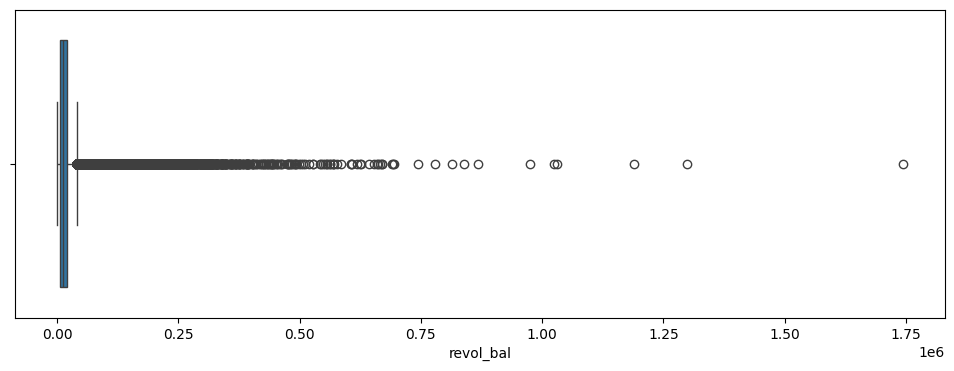

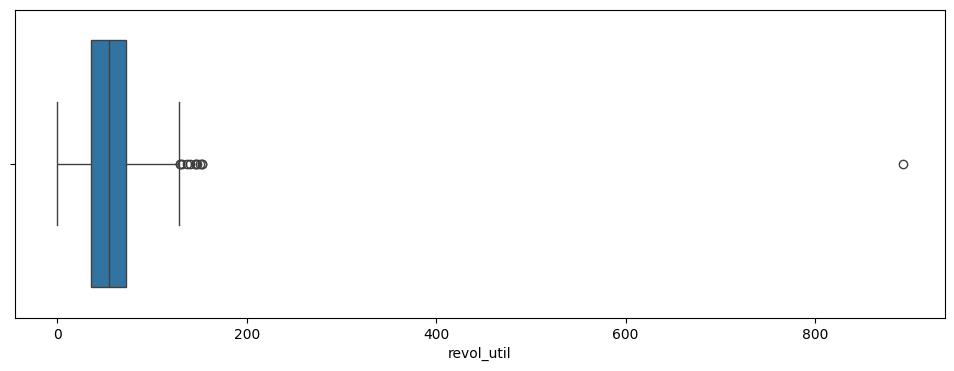

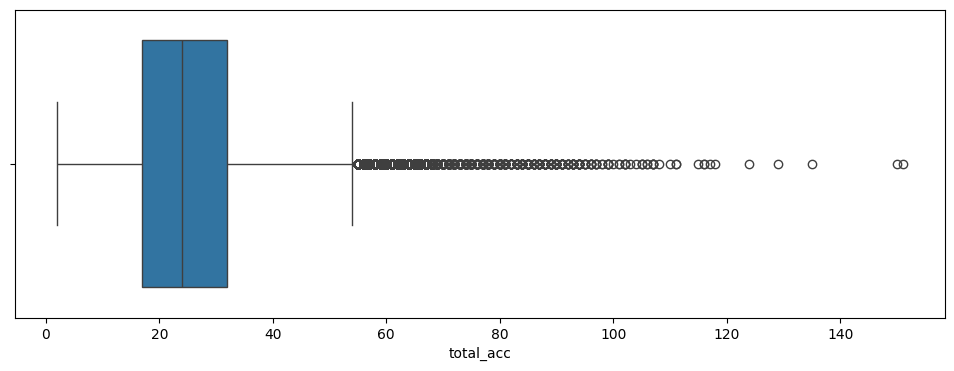

In [ ]:
for i in num_cols:
  plt.figure(figsize=(12,4))
  sns.boxplot(x=df1[i])
  plt.show()

Outliers are present since all the outliers are present towards upper limit so no lower limit outliers are ppresnt or just some

In [ ]:
df1.shape

(396030, 28)

In [ ]:
df2=df1.copy()

In [ ]:
df2.shape

(396030, 28)

In the project cannot use IQR (Inter quartile Range method) there will be lot of data loss cause there are outliers were loan amount and annual income are extreme but are real values so it cannot be ignored otherwise model become biased

We use log transformation and clipping method


Clipping :  Clipping is a data outlier handling method where all values greater than  the upper threshold are replaced with upper threshold value and all the values less than the lower threshold are replaced with lower threshold value

In [ ]:
for col in num_cols:
  lower=df2[col].quantile(0.01)
  upper=df2[col].quantile(0.99)

  df2[col]=np.clip(df2[col],lower,upper)

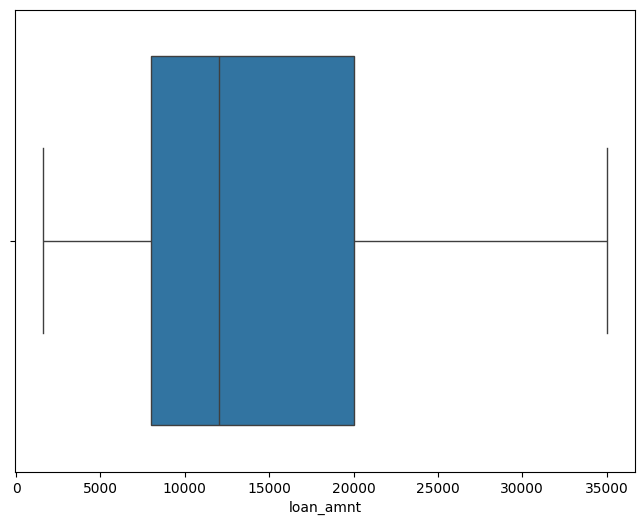

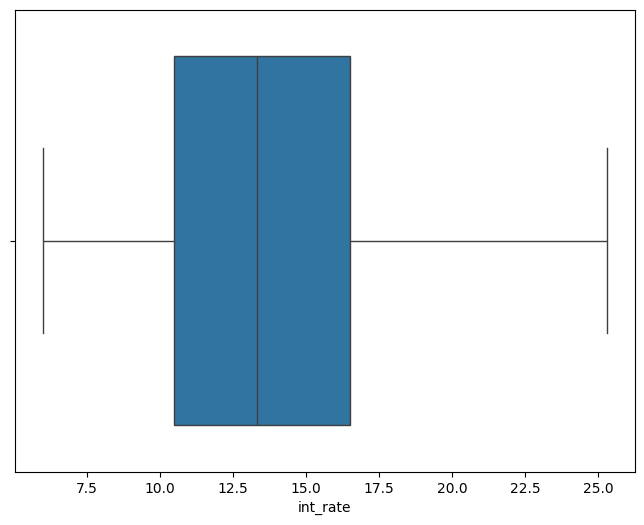

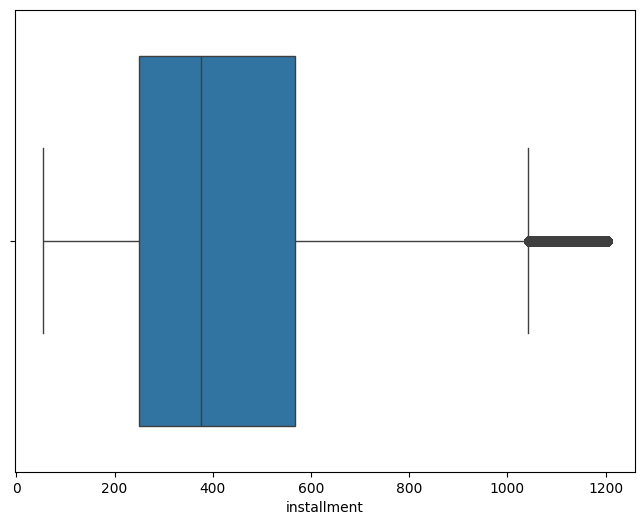

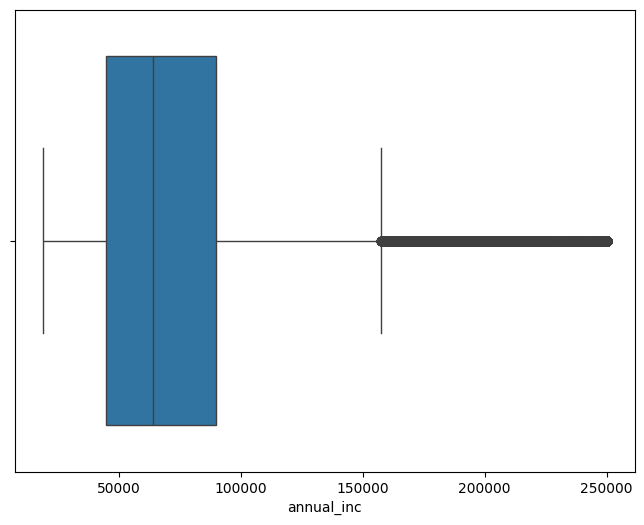

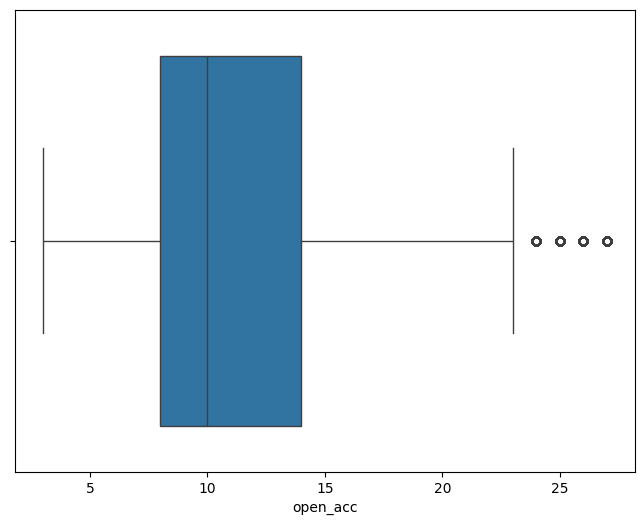

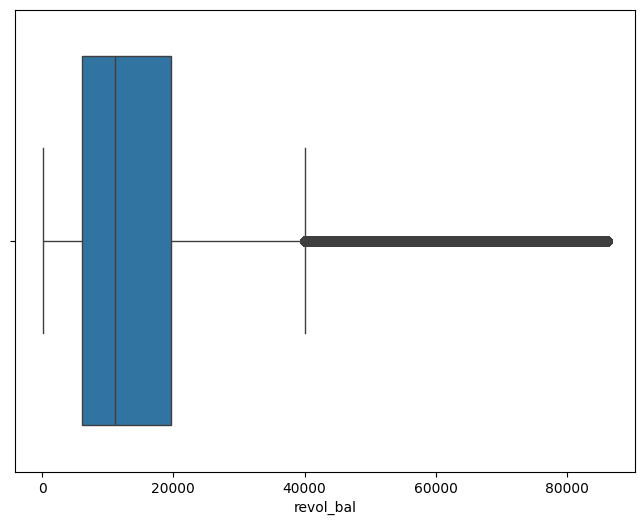

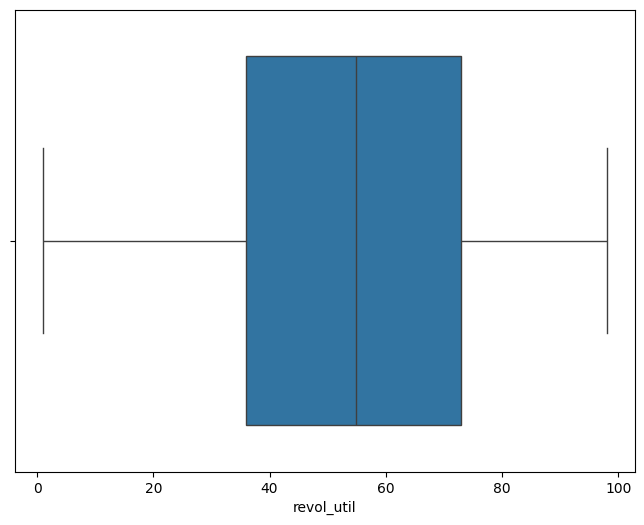

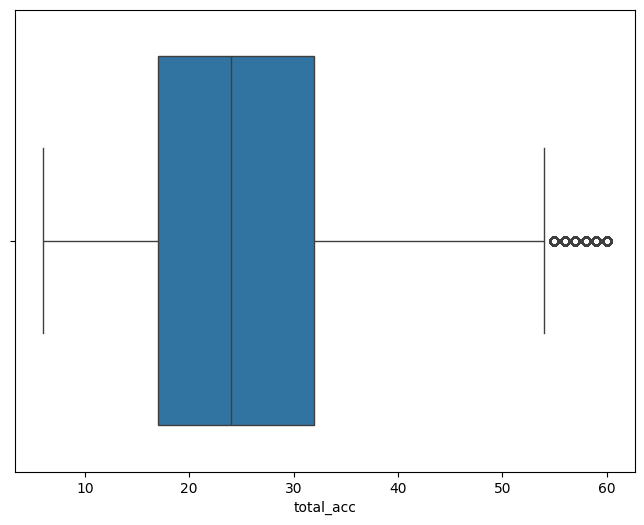

In [ ]:
for col in num_cols:
  plt.figure(figsize=(8,6))
  sns.boxplot(x=df2[col])
  plt.show()

The extreme outliers are reduced , some features have little outliers because the distribution is left skewed

In [ ]:
df2.shape

(396030, 28)

In [ ]:
df2.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address,zipcode
0,10000.0,36,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,0,36369.0,41.8,25.0,w,INDIVIDUAL,0,0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690",22690
1,8000.0,36,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,0,20131.0,53.3,27.0,f,INDIVIDUAL,1,0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113",05113
2,15600.0,36,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,0,11987.0,92.2,26.0,f,INDIVIDUAL,0,0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113",05113
3,7200.0,36,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,0,5472.0,21.5,13.0,f,INDIVIDUAL,0,0,"823 Reid Ford\r\nDelacruzside, MA 00813",00813
4,24375.0,60,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,0,24584.0,69.8,43.0,f,INDIVIDUAL,0,0,"679 Luna Roads\r\nGreggshire, VA 11650",11650


**Data** **preparation** **for** **modeling**


Hypothesis Testing to remove categorical variables that are not relevant to target variable using chi square test

Chi-Square Test : Chi square test is a hypothesis testing used to check  the if the two categorical variables are independent of each other or there is some association between them

Null Hypothesis : The two variables are independent of each other

Alternative Hypothesis : Association between two variables

significance value is alpha->0.05

In [ ]:
cat_cols=df2.select_dtypes('object').columns
cat_cols=['term', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'verification_status', 'issue_d',
       'purpose', 'title', 'earliest_cr_line', 'initial_list_status',
       'application_type', 'address', 'zipcode']


In [ ]:
from scipy.stats import chisquare,chi2_contingency

In [ ]:
def chi_testing(df2,cat_cols,target,features_to_remove):
  for col in cat_cols:
    print(col," : ")
    tab=pd.crosstab(df2[col],df2[target])
    t_stat,p,dof,freq=chi2_contingency(tab)
    print("p_value",p)
    if p>0.05:
      print("Null Hypothesis")
      print("The variables are not associated")
      features_to_remove.append(col)
    else:
      print("Alternate Hypothesis")
      print("The variables are associated")
    print("-"*50)
  print("Features not associated with Target variable :",features_to_remove)

In [ ]:
target='loan_status'
features_to_remove=[]
chi_testing(df2,cat_cols,target,features_to_remove)

term  : 
p_value 0.0
Alternate Hypothesis
The variables are associated
--------------------------------------------------
grade  : 
p_value 0.0
Alternate Hypothesis
The variables are associated
--------------------------------------------------
sub_grade  : 
p_value 0.0
Alternate Hypothesis
The variables are associated
--------------------------------------------------
emp_title  : 
p_value 0.12866359824898702
Null Hypothesis
The variables are not associated
--------------------------------------------------
emp_length  : 
p_value 3.0227223993214624e-182
Alternate Hypothesis
The variables are associated
--------------------------------------------------
home_ownership  : 
p_value 0.0
Alternate Hypothesis
The variables are associated
--------------------------------------------------
verification_status  : 
p_value 0.0
Alternate Hypothesis
The variables are associated
--------------------------------------------------
issue_d  : 
p_value 0.0
Alternate Hypothesis
The variables are associ

We have got 3 features that are not associated to target variable so drop those features from the Data frame

In [ ]:
df2.drop(columns=features_to_remove,inplace=True)

Numerical feature Using correaltion find the relevant feature to target variable loan status  

Visulaization using Heatmap

Convert target variable to numerical

In [ ]:
df2['loan_status']=df2['loan_status'].map({'Fully Paid':1,'Charged Off':0})

<Axes: >

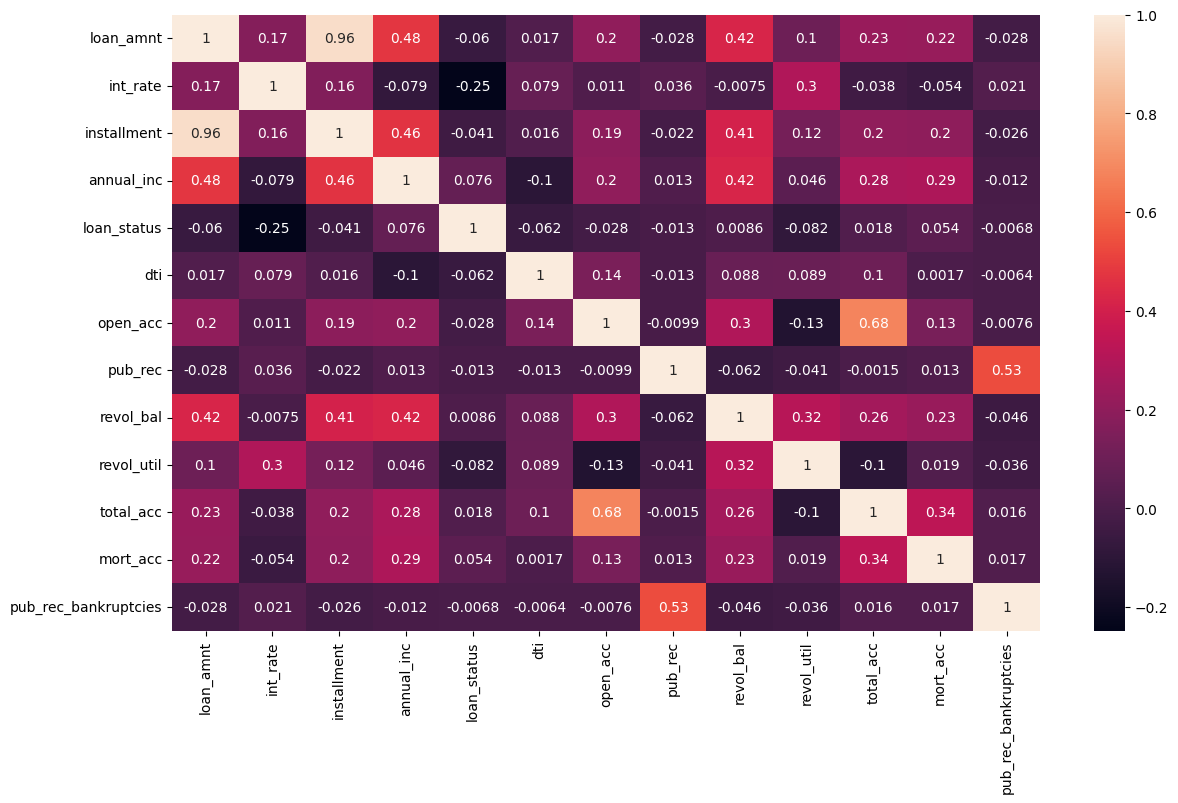

In [ ]:
plt.figure(figsize=(14,8))
sns.heatmap(df2.select_dtypes(['int','float']).corr(),annot=True)

Pearson correlation : Pearson correlation is used to measure the linear relationship between the variables

Null Hypothesis : The variables are independent of each other

Alternate Hypothesis : The variables are asscociated with each other

with significance level -> 0.05

In [ ]:
num_cols=df2.select_dtypes(['int','float']).columns
num_cols=['loan_amnt', 'int_rate', 'installment', 'annual_inc',
       'dti', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'mort_acc', 'pub_rec_bankruptcies']

In [ ]:
from scipy.stats import pearsonr

In [ ]:
def pearson_correlation(df2,num_cols,target,remove_features):
  for col in num_cols:
    print(col," : ")
    t_stat,p=pearsonr(df2[col],df2[target])
    print("P_Value : ",p)
    if p>0.05:
      print("Null Hypothesis")
      print("Variables are Independent")
      remove_features.append(col)
    else:
      print("Alternate Hypothesis")
      print("Variables are associated withn each other")
    print("-"*50)
  print("Feature To be Removed : ",remove_features)


In [ ]:
target='loan_status'
remove_features=[]
pearson_correlation(df2,num_cols,target,remove_features)

loan_amnt  : 
P_Value :  3.32523238902e-312
Alternate Hypothesis
Variables are associated withn each other
--------------------------------------------------
int_rate  : 
P_Value :  0.0
Alternate Hypothesis
Variables are associated withn each other
--------------------------------------------------
installment  : 
P_Value :  7.235676813845757e-147
Alternate Hypothesis
Variables are associated withn each other
--------------------------------------------------
annual_inc  : 
P_Value :  0.0
Alternate Hypothesis
Variables are associated withn each other
--------------------------------------------------
dti  : 
P_Value :  0.0
Alternate Hypothesis
Variables are associated withn each other
--------------------------------------------------
open_acc  : 
P_Value :  1.1562381067300277e-68
Alternate Hypothesis
Variables are associated withn each other
--------------------------------------------------
pub_rec  : 
P_Value :  1.0084293235477559e-16
Alternate Hypothesis
Variables are associated wi

All the Numerical values are highly Correlated to target value

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 25 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_length            396030 non-null  object 
 7   home_ownership        396030 non-null  object 
 8   annual_inc            396030 non-null  float64
 9   verification_status   396030 non-null  object 
 10  issue_d               396030 non-null  object 
 11  loan_status           396030 non-null  int64  
 12  purpose               396030 non-null  object 
 13  dti                   396030 non-null  float64
 14  earliest_cr_line      396030 non-null  object 
 15  

Converting categorical variable to numerical

In [ ]:
df2['term']=df2['term'].astype('int')

Grouping the None and ANY to other

In [ ]:
df2.loc[df2['home_ownership']=='NONE','home_ownership']='OTHER'
df2.loc[df2['home_ownership']=='ANY','home_ownership']='OTHER'
df2['home_ownership'].value_counts()

,count
home_ownership,
MORTGAGE,198348
RENT,159790
OWN,37746
OTHER,146


issue_d and earliest_sr_line does not add predictive value and cannot be simplified, it's better to remove it to reduce noise and model complexity.

In [ ]:
df2.drop(columns=['issue_d','earliest_cr_line'],inplace=True)

In [ ]:
df2['initial_list_status']=df2['initial_list_status'].map({'w':1,'f':0})

Since sub_grade has 35 unique values where we cannot do one hot encoding , we have Grade which higher impact , so it's okay to drop sub grade column

In [ ]:
df2.drop(columns=['sub_grade'],inplace=True)

In [ ]:
cat_cols=df2.select_dtypes('object').columns

performing one hot encoding on categorical data

In [ ]:
df2.shape

(396030, 22)

In [ ]:
for col in cat_cols:
  print(col," : ",df2[col].nunique())
  print("-"*50)

grade  :  7
--------------------------------------------------
emp_length  :  12
--------------------------------------------------
home_ownership  :  4
--------------------------------------------------
verification_status  :  3
--------------------------------------------------
purpose  :  14
--------------------------------------------------
application_type  :  3
--------------------------------------------------
zipcode  :  10
--------------------------------------------------


Based on the Results

conclusion is that :

For low cardinality Grade , home_ownership, verification_status,application type and zipcode let us use one Hot Encoding

For emp_length can use ordinality

For high cardinality like purpose can use the target encoding

One Hot encoding

In [ ]:
df_encoded=pd.get_dummies(df2,columns=['grade','home_ownership','verification_status','application_type','zipcode'],drop_first=True,dtype='int')
df_encoded.head()

,loan_amnt,term,int_rate,installment,emp_length,annual_inc,loan_status,purpose,dti,open_acc,...,application_type_JOINT,zipcode_05113,zipcode_11650,zipcode_22690,zipcode_29597,zipcode_30723,zipcode_48052,zipcode_70466,zipcode_86630,zipcode_93700
0,10000.0,36,11.44,329.48,10+ years,117000.0,1,vacation,26.24,16.0,...,0,0,0,1,0,0,0,0,0,0
1,8000.0,36,11.99,265.68,4 years,65000.0,1,debt_consolidation,22.05,17.0,...,0,1,0,0,0,0,0,0,0,0
2,15600.0,36,10.49,506.97,< 1 year,43057.0,1,credit_card,12.79,13.0,...,0,1,0,0,0,0,0,0,0,0
3,7200.0,36,6.49,220.65,6 years,54000.0,1,credit_card,2.60,6.0,...,0,0,0,0,0,0,0,0,0,0
4,24375.0,60,17.27,609.33,9 years,55000.0,0,credit_card,33.95,13.0,...,0,0,1,0,0,0,0,0,0,0


Splitting data based on Train ,Test

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X=df_encoded.drop(columns=['loan_status'])
y=df_encoded['loan_status']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

For High cardinality features let's perform Target encoding

Target Encoding : It gives mean value of each category with respect to target values

In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 4.0 MB/s eta 0:00:00


In [ ]:
from category_encoders import TargetEncoder

In [ ]:
encoder=TargetEncoder()
for col in list(df_encoded.select_dtypes('object').columns):
  X_train[col]=encoder.fit_transform(X_train[col],y_train)
  X_test[col]=encoder.transform(X_test[col])

In [ ]:
X_train.head()

,loan_amnt,term,int_rate,installment,emp_length,annual_inc,purpose,dti,open_acc,pub_rec,...,application_type_JOINT,zipcode_05113,zipcode_11650,zipcode_22690,zipcode_29597,zipcode_30723,zipcode_48052,zipcode_70466,zipcode_86630,zipcode_93700
44819,25000.0,60,14.83,592.52,0.815671,109000.0,0.704516,13.90,11.0,0,...,0,0,0,0,0,0,0,0,0,1
41622,9500.0,36,12.99,320.05,0.723776,40000.0,0.779070,22.29,6.0,0,...,0,0,0,0,0,0,1,0,0,0
362594,9000.0,36,8.39,283.65,0.815671,50000.0,0.792433,15.27,14.0,0,...,0,1,0,0,0,0,0,0,0,0
228739,16700.0,60,22.99,470.69,0.805602,68000.0,0.792433,21.92,13.0,0,...,0,0,0,0,0,0,0,0,0,0
210327,2800.0,36,15.80,98.17,0.798315,218554.0,0.829213,14.93,20.0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X_test.head()

,loan_amnt,term,int_rate,installment,emp_length,annual_inc,purpose,dti,open_acc,pub_rec,...,application_type_JOINT,zipcode_05113,zipcode_11650,zipcode_22690,zipcode_29597,zipcode_30723,zipcode_48052,zipcode_70466,zipcode_86630,zipcode_93700
286468,3000.0,36,21.18,113.31,0.806375,25000.0,0.832538,12.05,9.0,0,...,0,0,0,0,0,0,0,1,0,0
232995,10000.0,36,15.31,348.18,0.807146,45000.0,0.792433,15.52,15.0,0,...,0,0,0,0,0,0,0,1,0,0
185417,25000.0,36,10.99,818.35,0.804044,105000.0,0.792433,16.65,22.0,0,...,0,0,0,0,0,0,0,1,0,0
106511,16425.0,36,19.20,603.74,0.804044,37000.0,0.832538,26.53,8.0,0,...,0,0,0,0,0,0,0,0,1,0
108751,30000.0,36,14.65,1034.83,0.809275,97500.0,0.792433,21.19,12.0,0,...,0,0,0,0,1,0,0,0,0,0


Scaling:

Standard Scaling scales features so that mean = 0 and standard deviation = 1, making features comparable. It is commonly used for logistic regression and other gradient-based models to help convergence. However, it is sensitive to outliers — extreme values can still affect the scaling.

                           x_scaled = (x - mean) / std

	​


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()
X_train_scaled=pd.DataFrame(scaler.fit_transform(X_train),columns=X_train.columns)
X_test_scaled=pd.DataFrame(scaler.transform(X_test),columns=X_test.columns)

In [ ]:
X_train_scaled.head()

,loan_amnt,term,int_rate,installment,emp_length,annual_inc,purpose,dti,open_acc,pub_rec,...,application_type_JOINT,zipcode_05113,zipcode_11650,zipcode_22690,zipcode_29597,zipcode_30723,zipcode_48052,zipcode_70466,zipcode_86630,zipcode_93700
0,1.303387,1.792461,0.269649,0.647513,0.645745,0.891769,-4.170471,-0.176538,-0.054697,-0.143963,...,-0.033256,-0.359102,-0.170833,-0.408272,-0.359801,-0.408997,-0.404835,-0.410794,-0.168846,5.874557
1,-0.552498,-0.557892,-0.145252,-0.447419,-4.202063,-0.815228,-1.027095,0.248684,-1.068182,-0.143963,...,-0.033256,-0.359102,-0.170833,-0.408272,-0.359801,-0.408997,2.470143,-0.410794,-0.168846,-0.170226
2,-0.612365,-0.557892,-1.182505,-0.593693,0.645745,-0.567838,-0.463666,-0.107104,0.553394,-0.143963,...,-0.033256,2.784727,-0.170833,-0.408272,-0.359801,-0.408997,-0.404835,-0.410794,-0.168846,-0.170226
3,0.309591,1.792461,2.109646,0.157934,0.114576,-0.122534,-0.463666,0.229931,0.350697,-0.143963,...,-0.033256,-0.359102,-0.170833,-0.408272,-0.359801,-0.408997,-0.404835,-0.410794,-0.168846,-0.170226
4,-1.354719,-0.557892,0.488374,-1.339052,-0.269839,3.602035,1.087044,-0.124336,1.769576,-0.143963,...,-0.033256,-0.359102,-0.170833,-0.408272,-0.359801,-0.408997,-0.404835,-0.410794,-0.168846,-0.170226


In [ ]:
X_train_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316824 entries, 0 to 316823
Data columns (total 38 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   loan_amnt                            316824 non-null  float64
 1   term                                 316824 non-null  float64
 2   int_rate                             316824 non-null  float64
 3   installment                          316824 non-null  float64
 4   emp_length                           316824 non-null  float64
 5   annual_inc                           316824 non-null  float64
 6   purpose                              316824 non-null  float64
 7   dti                                  316824 non-null  float64
 8   open_acc                             316824 non-null  float64
 9   pub_rec                              316824 non-null  float64
 10  revol_bal                            316824 non-null  float64
 11  revol_util   

Before Performing Modeling we should check Multi collinearity using VIF means if the input features are highly correlated or not correalted

VIF(Variance Inflation Factor): measures the multi collinearity between input features

if VIF>10 High multi collinearity

if VIF>5 AND VIF<=10 multi collinearitry exists

if VIF<=5 little multi collinearity (acceptable)

if VIF=1 No multi collinearity

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
x_t=X_train_scaled.copy()
cols=list(x_t.columns)

In [ ]:
def calc_vif(x):
  vif=pd.DataFrame({'Features':x.columns})
  vif['VIF']=[variance_inflation_factor(x.values,i) for i in range(x.shape[1])]
  vif=vif.sort_values(by='VIF',ascending=False)
  return vif

In [ ]:
print(calc_vif(x_t))

                               Features        VIF
0                             loan_amnt  63.398061
3                           installment  54.938576
2                              int_rate  12.644205
18                              grade_D   9.753733
19                              grade_E   8.677704
17                              grade_C   7.494444
1                                  term   6.978787
20                              grade_F   5.691685
16                              grade_B   3.755615
27          application_type_INDIVIDUAL   2.523245
28               application_type_JOINT   2.520835
21                              grade_G   2.424287
12                            total_acc   2.157752
8                              open_acc   2.081384
35                        zipcode_70466   1.927755
33                        zipcode_30723   1.922306
31                        zipcode_22690   1.919881
34                        zipcode_48052   1.909212
32                        zipco

loan amount and installement has highest VIF means high collinearity let's remove installment and check

In [ ]:
cols.remove('installment')

In [ ]:
print(calc_vif(x_t[cols]))

                               Features        VIF
2                              int_rate  11.941254
17                              grade_D   9.747295
18                              grade_E   8.677449
16                              grade_C   7.485724
19                              grade_F   5.688601
15                              grade_B   3.751624
26          application_type_INDIVIDUAL   2.523244
27               application_type_JOINT   2.520835
20                              grade_G   2.416249
11                            total_acc   2.157721
7                              open_acc   2.080104
34                        zipcode_70466   1.927755
32                        zipcode_30723   1.922306
30                        zipcode_22690   1.919881
33                        zipcode_48052   1.909212
0                             loan_amnt   1.773782
31                        zipcode_29597   1.763779
28                        zipcode_05113   1.761533
9                             r

Intrest Rate has highest VIF score so let's remove and see whether Multi collinearity reduces

In [ ]:
cols.remove('int_rate')

In [ ]:
print(calc_vif(x_t[cols]))

                               Features       VIF
25          application_type_INDIVIDUAL  2.522884
26               application_type_JOINT  2.520266
15                              grade_C  2.299971
10                            total_acc  2.156003
14                              grade_B  2.130178
16                              grade_D  2.077500
6                              open_acc  2.076532
33                        zipcode_70466  1.927755
31                        zipcode_30723  1.922306
29                        zipcode_22690  1.919881
32                        zipcode_48052  1.909211
17                              grade_E  1.786639
0                             loan_amnt  1.772039
30                        zipcode_29597  1.763779
27                        zipcode_05113  1.761532
8                             revol_bal  1.666596
24         verification_status_Verified  1.627591
3                            annual_inc  1.580343
1                                  term  1.529735


we have removed Multi collinearity and now multi collinearity is less than 5

In [ ]:
# Selecting columns with no or little multi collinearity
X_train_scaled=X_train_scaled[cols]
X_test_scaled=X_test_scaled[cols]

In [ ]:
X_train_scaled.head()

,loan_amnt,term,emp_length,annual_inc,purpose,dti,open_acc,pub_rec,revol_bal,revol_util,...,application_type_JOINT,zipcode_05113,zipcode_11650,zipcode_22690,zipcode_29597,zipcode_30723,zipcode_48052,zipcode_70466,zipcode_86630,zipcode_93700
0,1.303387,1.792461,0.645745,0.891769,-4.170471,-0.176538,-0.054697,-0.143963,-0.621712,-0.503908,...,-0.033256,-0.359102,-0.170833,-0.408272,-0.359801,-0.408997,-0.404835,-0.410794,-0.168846,5.874557
1,-0.552498,-0.557892,-4.202063,-0.815228,-1.027095,0.248684,-1.068182,-0.143963,3.348867,1.184253,...,-0.033256,-0.359102,-0.170833,-0.408272,-0.359801,-0.408997,2.470143,-0.410794,-0.168846,-0.170226
2,-0.612365,-0.557892,0.645745,-0.567838,-0.463666,-0.107104,0.553394,-0.143963,-0.448731,-1.255572,...,-0.033256,2.784727,-0.170833,-0.408272,-0.359801,-0.408997,-0.404835,-0.410794,-0.168846,-0.170226
3,0.309591,1.792461,0.114576,-0.122534,-0.463666,0.229931,0.350697,-0.143963,0.588026,0.062919,...,-0.033256,-0.359102,-0.170833,-0.408272,-0.359801,-0.408997,-0.404835,-0.410794,-0.168846,-0.170226
4,-1.354719,-0.557892,-0.269839,3.602035,1.087044,-0.124336,1.769576,-0.143963,1.261911,1.516956,...,-0.033256,-0.359102,-0.170833,-0.408272,-0.359801,-0.408997,-0.404835,-0.410794,-0.168846,-0.170226


In [ ]:
X_test_scaled.head()

,loan_amnt,term,emp_length,annual_inc,purpose,dti,open_acc,pub_rec,revol_bal,revol_util,...,application_type_JOINT,zipcode_05113,zipcode_11650,zipcode_22690,zipcode_29597,zipcode_30723,zipcode_48052,zipcode_70466,zipcode_86630,zipcode_93700
0,-1.330772,-0.557892,0.155358,-1.186315,1.227231,-0.270300,-0.460091,-0.143963,-0.852920,-0.857149,...,-0.033256,-0.359102,-0.170833,-0.408272,-0.359801,-0.408997,-0.404835,2.434311,-0.168846,-0.170226
1,-0.492631,-0.557892,0.196029,-0.691533,-0.463666,-0.094433,0.756091,-0.143963,-0.442858,-0.150668,...,-0.033256,-0.359102,-0.170833,-0.408272,-0.359801,-0.408997,-0.404835,2.434311,-0.168846,-0.170226
2,1.303387,-0.557892,0.032354,0.792812,-0.463666,-0.037163,2.174970,-0.143963,1.403763,0.186143,...,-0.033256,-0.359102,-0.170833,-0.408272,-0.359801,-0.408997,-0.404835,2.434311,-0.168846,-0.170226
3,0.276664,-0.557892,0.032354,-0.889446,1.227231,0.463575,-0.662788,-0.143963,0.159924,0.974773,...,-0.033256,-0.359102,-0.170833,-0.408272,-0.359801,-0.408997,-0.404835,-0.410794,5.922543,-0.170226
4,1.902060,-0.557892,0.308310,0.607269,-0.463666,0.192933,0.148000,-0.143963,0.376345,-0.536768,...,-0.033256,-0.359102,-0.170833,-0.408272,2.779311,-0.408997,-0.404835,-0.410794,-0.168846,-0.170226


Model building

Build the Logistic Regression model and comment on the model statistics


Logistic regression is a supervised Machine learning approach for classification tasks where the data points are linearly seperable by a hyperplane.

$$
\hat{y} = \sigma(w \cdot x + b)
$$

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$


Assumptions of Logistic Regression :

1. Logistic regression assumes that log odds of dependent variable is linear combination of indepenent variable

$$
\log\left(\frac{p}{1 - p}\right) = w \cdot x + b
$$


2. Little or No Multi collinearity between the input variables


### ⚙️ Logistic Regression Loss Function

The **Loss function** for Logistic Regression is the **Binary Cross-Entropy (Log Loss)**:

$$
L = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]
$$

where:  
- \( m \) = number of samples  
- \( y^{(i)} \) = true label (0 or 1)  
- \( \hat{y}^{(i)} \) = predicted probability \( P(y=1|x^{(i)}) \)

---

**Intuition**

- If \( y = 1 \):  
  Only the first term matters →  
  \( L = -\log(\hat{y}) \)  
  (We want \( \hat{y} \) close to 1.)

- If \( y = 0 \):  
  Only the second term matters →  
  \( L = -\log(1 - \hat{y}) \)  
  (We want \( \hat{y} \) close to 0.)


  Derivative of loss function:

  L=-(y-y_pred)*x




### ⚙️ Derivative of Logistic Regression Loss

the derivative of the loss with respect to the weights \(w\) is:

$$
\frac{\partial L}{\partial w} = -(y - \hat{y}) \cdot x
$$  
where:  
- \( \hat{y} = \sigma(w \cdot x + b) \) is the predicted probability  
- \( y \) = true label (0 or 1)  
- \( x \) = input feature vector  



> which is equivalent because \((\hat{y} - y) = -(y - \hat{y})\).

---

#Interpretation
  
- In gradient descent, weights are updated as:  
$$
w = w - \alpha \cdot \frac{\partial L}{\partial w}
$$
where (alpha) is the learning rate.


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model=LogisticRegression()
model.fit(X_train_scaled,y_train)

LogisticRegression()

In [ ]:
y_pred=model.predict(X_test_scaled)
y_pred

array([1, 1, 1, ..., 1, 1, 1])

In [ ]:
print("Train Accuracy :",model.score(X_train_scaled,y_train))
print("Test Accuracy  :",model.score(X_test_scaled,y_test))

Train Accuracy : 0.8890740600459561
Test Accuracy  : 0.8903870918869783


Test accuracy is greater than Train accuracy

Display model coefficients with column names


In [ ]:
Coeffecients=pd.DataFrame({'Features':X_train_scaled.columns,'coeffecients':model.coef_.flatten()})
Coeffecients=Coeffecients.sort_values(by='coeffecients',ascending=False)
Coeffecients

,Features,coeffecients
27,zipcode_05113,1.977376
30,zipcode_29597,1.964364
3,annual_inc,0.169892
2,emp_length,0.114852
10,total_acc,0.106730
8,revol_bal,0.079200
4,purpose,0.061347
12,mort_acc,0.032125
26,application_type_JOINT,0.031862
20,home_ownership_OTHER,-0.005812


In [ ]:
y_train.value_counts()

,count
loan_status,
1,254546
0,62278


Data is imbalanced

1 - > 80% of Data

0 - > 20% of Data

For Imbalanced Dataset we can use class weight to increase the weights of minority class , class weight gives high impotance to the minority class and modfel improves it's accuracy

In [ ]:
model=LogisticRegression(class_weight='balanced')
model.fit(X_train_scaled,y_train)

LogisticRegression(class_weight='balanced')

In [ ]:
print("Train data :",model.score(X_train_scaled,y_train))
print("Test data  :",model.score(X_test_scaled,y_test))

Train data : 0.7982917960760548
Test data  : 0.7976037168901345


Train data and Test data accuracy are similr , yet we have to find precision , recall and f1 score to validate

Regularization:

Regularization is a technique used to reduce the overfitting in a model by penalizing large weights .

L1 Regularization:

L1 regularization techinque that adds penalty term proportional to absolute value of weights that reduces irrelevant features to zero , It can be used as feature selection

### **Loss Function (L1 Regularization)**

The loss function is:

$$
\text{Loss} = -\frac{1}{m} \sum_{i=1}^{m} \Big[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \Big] + \frac{1}{C} \sum_{j=1}^{n} |w_j|
$$

Where:  
- \(m\) = number of samples  
- \(y_i\) = true label (0 or 1)  
- \(\hat{y}_i = \sigma(w \cdot x_i + b)\) = predicted probability  
- \(C\) = inverse of regularization strength  
- \(w_j\) = weight of feature \(j\)  

**Interpretation:**  
- Smaller C → stronger regularization → more weights shrink to zero  
- Larger C → weaker regularization → less penalty  
- L1 penalty (Lasso) can **reduce irrelevant feature weights to exactly zero**, performing **feature selection**.


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param={'C':1/np.array([70000,1000000])}
model=LogisticRegression(class_weight='balanced')
rd=RandomizedSearchCV(estimator=model,param_distributions=param,cv=5,n_iter=10,verbose=2,scoring='f1')
rd.fit(X_train_scaled,y_train)

In [ ]:
print("Best_estimator : ",rd.best_estimator_)
print("Score : ",rd.score(X_train_scaled,y_train))

Best_estimator :  LogisticRegression(C=np.float64(1e-06), class_weight='balanced')
Score :  0.9074136011111942


In [ ]:
l1_model=rd.best_estimator_
l1_model

LogisticRegression(C=np.float64(1e-06), class_weight='balanced')

In [ ]:
print("Train :",l1_model.score(X_train_scaled,y_train))
print("Test  :",l1_model.score(X_test_scaled,y_test))

Train : 0.8514632729843699
Test  : 0.8509456354316592


L1 Regularization and Class weight method has increased the accuracy

L2 Regularization:

L2 regularization technique adds penalty term proportional to square of weights to reduce the irrelavant features close to zero but not zero , it can be used if all features are important


$$
\text{Loss} = -\frac{1}{m} \sum_{i=1}^{m} \Big[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \Big] + \frac{1}{C} \sum_{j=1}^{n} w_j^2
$$

Where:  
- \(m\) = number of samples  
- \(y_i\) = true label (0 or 1)  
- \(\hat{y}_i = \sigma(w \cdot x_i + b)\) = predicted probability  
- \(C\) = inverse of regularization strength  
- \(w_j\) = weight of feature \(j\)  

**Interpretation:**  
- Smaller C → stronger regularization → weights shrink more  
- Larger C → weaker regularization → less penalty  
- L2 penalty reduces irrelevant feature weights **close to zero**, b

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param={'C':1/np.array([1000,10000,100000,10000000])}
model=LogisticRegression(class_weight='balanced',penalty='l2')
rd=RandomizedSearchCV(estimator=model,param_distributions=param,cv=5,n_iter=10,verbose=1,scoring='f1')
rd.fit(X_train_scaled,y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=5, estimator=LogisticRegression(class_weight='balanced'),
                   param_distributions={'C': array([1.e-03, 1.e-04, 1.e-05, 1.e-07])},
                   scoring='f1', verbose=1)

In [ ]:
print("Best Estimator :",rd.best_estimator_)
print("Score :",rd.score(X_train_scaled,y_train))

Best Estimator : LogisticRegression(C=np.float64(1e-07), class_weight='balanced')
Score : 0.9074342147906481


In [ ]:
l2_model=rd.best_estimator_
l2_model

LogisticRegression(C=np.float64(1e-07), class_weight='balanced')

In [ ]:
print('Train :',l2_model.score(X_train_scaled,y_train))
print('Test  :',l2_model.score(X_test_scaled,y_test))

Train : 0.8512517991061284
Test  : 0.8510971391056233


Results Evaluation

ROC AUC Curve & comments

Receiver Operating Characteristic curve:

The plot of True positive Rate(Y axis) vs False Positive Rate(X axis)

True Positive Rate = True positive/(True Positive + False Negative)

False positive Rate = False Positive/(False Positive + True Negative)

ROC AUC curve is best compared to Recall,precision

Recall and Precision changes if threshold changes the recall and precision

ROC AUC curve is for all thresholds so best threshold is taken but considering Area under the curve

In [ ]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

In [ ]:
from sklearn.metrics import roc_auc_score,roc_curve

In [ ]:
y_pred_prob=l2_model.predict_proba(X_test_scaled)[:,1]

ROC Score : 0.8609120626498553


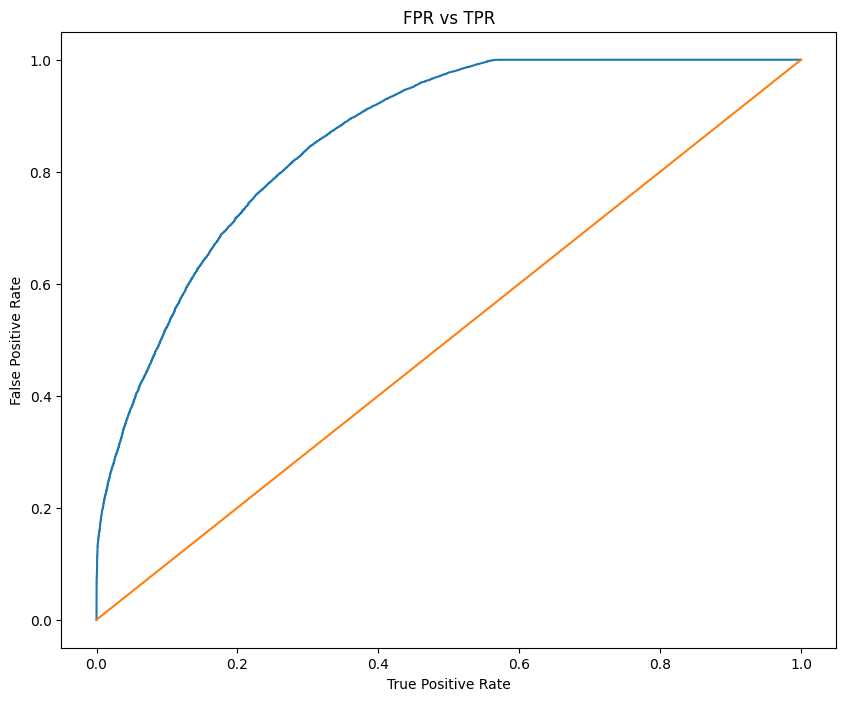

In [ ]:
plt.figure(figsize=(10,8))
score=roc_auc_score(y_test,y_pred_prob)
print("ROC Score :",score)
fpr,tpr,threshold=roc_curve(y_test,y_pred_prob)
plt.plot(fpr,tpr)
plt.plot(fpr,fpr)
plt.xlabel("True Positive Rate")
plt.ylabel("False Positive Rate")
plt.title("FPR vs TPR")
plt.show()

The model performs significantly better than random (0.5) in distinguishing between positive and negative classes.


With an AUC of 0.86091, the model correctly ranks a positive instance higher than a negative instance ~86% of the time.


ROC does'nt work well for imbalanced dataset

ROC considers order of probability not probability

Precision Recall Curve & comments


It is a plot between Precision (Y-axis) and Recall (X-axis) for different classification thresholds.

The PR curve shows how Precision and Recall trade off as the decision threshold changes.

It is well-suited for imbalanced datasets, since it focuses on the positive (minority) class performance.

The PR curve handles threshold variation because Precision and Recall are computed at each threshold, and the curve summarizes their relationship across all thresholds.

In [ ]:
from sklearn.metrics import average_precision_score,precision_recall_curve

In [ ]:
y_pred_prob=l2_model.predict_proba(X_test_scaled)[:,1]

Average Precision score :  0.956042773083631


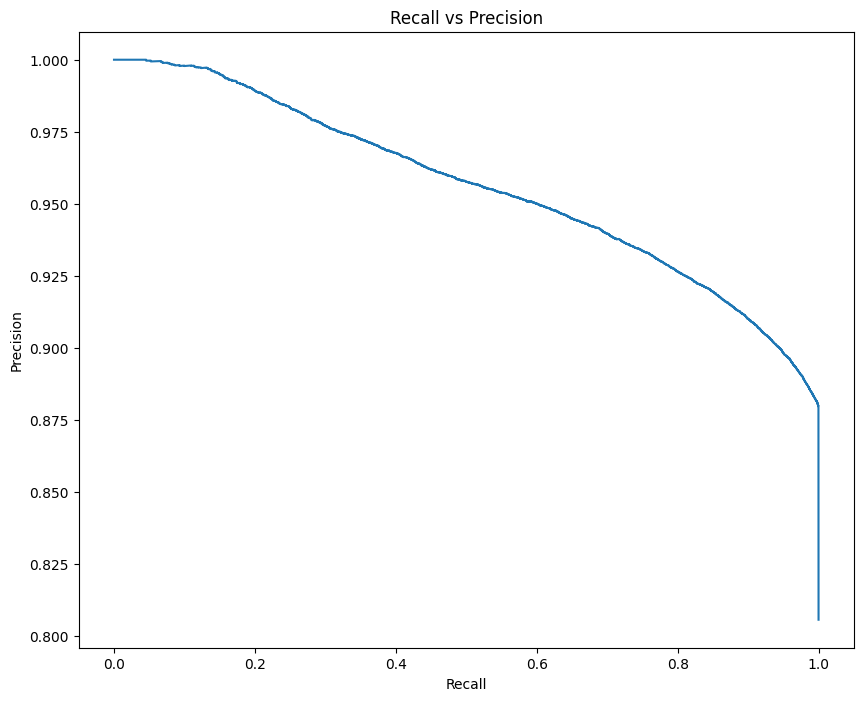

In [ ]:
plt.figure(figsize=(10,8))
score=average_precision_score(y_test,y_pred_prob)
print("Average Precision score : ",score)
precision,recall,threshold=precision_recall_curve(y_test,y_pred_prob)
plt.plot(recall,precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Recall vs Precision')
plt.show()

Average Precision (PR) = 0.956, showing the model accurately identifies positive (minority) instances and outperforms a random baseline on this imbalanced dataset

Classification Report (Confusion Matrix)

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay

In [ ]:
cm=confusion_matrix(y_test,l2_model.predict(X_test_scaled))
cm

array([[ 9602,  5793],
       [ 6001, 57810]])

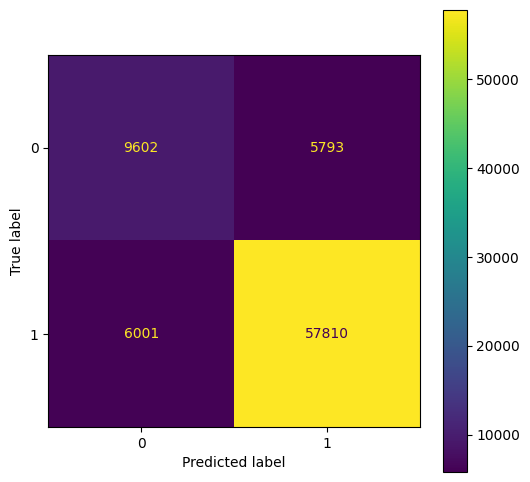

In [ ]:
fig,ax=plt.subplots(figsize=(6,6))
ConfusionMatrixDisplay(cm).plot(ax=ax)

Confusion Matrix :

True Positive - 57810

True Negative - 9602

False Positive - 5793

False Negative - 6001

classification report

Precision : out of all samples model predicted as class 1 , how many were correctly predicted as class 1 by the model

Precision = True Positive/(True positive + False Positive)

Recall : Out of actual class 1 ,how many were correctly predicted as class 1 by the model

Recall= True positive/(True Positive+False Negative)

F1 score : F1 score is Harmonic mean of precision and recall

F1=2*(Precision*Recall)/(Precision+Recall)

In [ ]:
y_pred=l2_model.predict(X_test_scaled)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.62      0.62      0.62     15395
           1       0.91      0.91      0.91     63811

    accuracy                           0.85     79206
   macro avg       0.76      0.76      0.76     79206
weighted avg       0.85      0.85      0.85     79206



Classification report:

Class 0:

Precision : Out of all samples model predicted class 0 , 62% are correctly predicted as class 0

Recall : Out of actual class 0 , 62% were correctly predicted

F1 score : 62%

Class 1:

precision : Out of all samples model predicted class 1, 91% are correctly predicted as class 1

Recall : out of actual class 1 , 91% were correctly predicted as class 1

F1 score : 91%

Tradeoff Questions

How can we make sure that our model can detect real defaulters and there are less false positives? This is important as we can lose out on an opportunity to finance more individuals and earn interest on it ?


We have to reduce False positive that is type 1 error , By using precision we can detect the real defaulters , by increasing precision we can reduce False positive for class 1

Since NPA (non-performing asset) is a real problem in this industry, it’s important we play safe and shouldn’t disburse loans to anyone ?

Type 2 error that is False Negative should be reduced cause actual real defaulters are correctly predicted, increasing Recall that out of actual class 1 , 91% correctly predicted as class 1 so only 9 % is False negative. Increasing Recall decreases False Negative so we can disburse loan safely

**Actionable Insights & Recommendations**

1. Categorical variable impact on target variable loan status
      - 60 month term payment has high defaulters
      - The majority people have home ownership as mortage
      - Grade B has highest people repayment of loan
      - Grade C has highest defaulters comapred to other
      - Grade has higher impact on loan status
      - zipcode_05113 , zipcode_29597,zipcode_11650 and zipcode_93700 has higher coeffecient so it has high impact on the target variable
      - Emp length of 10+ years has highest repayment loan and high defaulters
      - emp_title,title, address are removed do not have impact on target
2. Numerical variable imapct on target variable loan status
      - The mean amount of loan amount,int rate,installement,revol util and open_acc are higher for defaulters
      - The mean of annual income is lower for defaulters
3. A Logistic Regression model (trained after upsampling the data to balance the target variable) performed well, rendering accuracy of 85%.

4. The model has a precision score of 62%,recall score of 62% and f1 score of 62% for negative (majority class)

5. The model has a precision score of 91%, recall score of 91%and f1 score of 91% for positive (minority class)

6. The ROC curve score is 0.86 signifies the model is able to differtiate between both classes

7. The area under precision recall curve is 0.95

8. In this specific case we focus more on defaulters , so precisiona and recall for positive class 1 should be high

1. What percentage of customers have fully paid their Loan Amount?
  - 80% of customers have fully paid their Loan Amount
2. Comment about the correlation between Loan Amount and Installment features.
  - Loan Amount and Installment features are highly correlated leading to multi collinearity

3. The majority of people have home ownership
  - Mortage
4. People with grades ‘A’ are more likely to fully pay their loan.
  - True people with Grade A are more likely to pay thier loan fully
5. Name the top 2 afforded job titles.
  - Teacher	and Manager
6. Which were the features that heavily affected the outcome?
   - zipcode_05113 , zipcode_29597,zipcode_11650 and zipcode_93700 were highly affected


**Recommendations**

- The optimal strategy to achieve the objective of balancing the risk of increasing NPAs by disbursing loans to defaulters with the opportunity to earn interest by disbursing loans to as many worthy customers as possible: maximise the F1 score along with the area under Precision Recall Curve (precision-recall trade-off)
- More complex classifiers like random forest would give better results compared to logistic regression because they are not restricted by the linearity of decision boundary
